In [25]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/")
from mrvis.utils.matplotlib_style import gcolor

filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_solar_wind"

all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)

print("Found {} files".format(number_of_files))

Found 109 files


Processing /home/max/Temp/reconnection_rates_step_0001.txt
Processing /home/max/Temp/reconnection_rates_step_0002.txt
Processing /home/max/Temp/reconnection_rates_step_0003.txt
Processing /home/max/Temp/reconnection_rates_step_0004.txt
Processing /home/max/Temp/reconnection_rates_step_0005.txt
Processing /home/max/Temp/reconnection_rates_step_0006.txt
Processing /home/max/Temp/reconnection_rates_step_0007.txt
Processing /home/max/Temp/reconnection_rates_step_0008.txt
Processing /home/max/Temp/reconnection_rates_step_0009.txt
Processing /home/max/Temp/reconnection_rates_step_0010.txt
Processing /home/max/Temp/reconnection_rates_step_0011.txt
Processing /home/max/Temp/reconnection_rates_step_0012.txt
Processing /home/max/Temp/reconnection_rates_step_0013.txt
Processing /home/max/Temp/reconnection_rates_step_0014.txt
Processing /home/max/Temp/reconnection_rates_step_0015.txt
Processing /home/max/Temp/reconnection_rates_step_0016.txt
Processing /home/max/Temp/reconnection_rates_step_0017.t

/tmp/ipykernel_116133/4191730541.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0001.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/4191730541.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0002.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/4191730541.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0003.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/4191730541.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0004.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/4191730541.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0005.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/4191730541.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0006.txt"
  data = np.loadtxt(datapath)
/tmp

Processing /home/max/Temp/reconnection_rates_step_0043.txt
Processing /home/max/Temp/reconnection_rates_step_0044.txt
Processing /home/max/Temp/reconnection_rates_step_0045.txt
Processing /home/max/Temp/reconnection_rates_step_0046.txt
Processing /home/max/Temp/reconnection_rates_step_0047.txt
Processing /home/max/Temp/reconnection_rates_step_0048.txt
Processing /home/max/Temp/reconnection_rates_step_0049.txt
Processing /home/max/Temp/reconnection_rates_step_0050.txt
Processing /home/max/Temp/reconnection_rates_step_0051.txt
Processing /home/max/Temp/reconnection_rates_step_0052.txt
Processing /home/max/Temp/reconnection_rates_step_0053.txt
Processing /home/max/Temp/reconnection_rates_step_0054.txt
Processing /home/max/Temp/reconnection_rates_step_0055.txt
Processing /home/max/Temp/reconnection_rates_step_0056.txt
Processing /home/max/Temp/reconnection_rates_step_0057.txt
Processing /home/max/Temp/reconnection_rates_step_0058.txt
Processing /home/max/Temp/reconnection_rates_step_0059.t

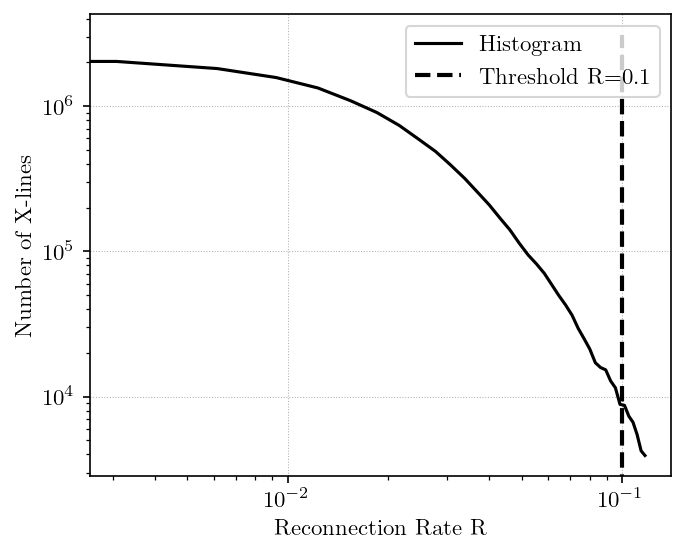

In [23]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    if len(data) == 0:
        print(f"Warning: No data found in {datapath}. Skipping.")
        return 0.0, np.array([])
    # data2 = np.loadtxt(all_files[60])
    # data = np.copy(data[np.where(data > 0.0)])
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    # x2, bins2 = np.histogram(data2, bins=bins, density=True)
    # plt.plot(bins[:-1], x2, ".-", linewidth=1.5, color=gradient[step], label=f"Step {step + 1}")
    # plt.hist(data, bins=bins, density=False, color="orange", label="$t=70/\Omega_{ci}$", rwidth=0.8)
    # plt.show()
    return np.max(x), data


bins=40  
max_reconnection_rate = 0.12

plt.figure(figsize=(5,4), dpi=150)

max_val = 0.0
all_data = np.array([])
for i, datapath in enumerate(all_files):
    print(f"Processing {datapath}")
    max_val_new, data = plot_histogram(i, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)
    all_data = np.concatenate((all_data, data))
    if max_val_new > max_val:
        max_val = max_val_new
        
    

bins = np.linspace(0.0, max_reconnection_rate, bins) 
x, bins = np.histogram(all_data, bins=bins, density=False)
plt.plot(bins[:-1], x, linewidth=1.5, color="black", label="Histogram")
max_val = np.max(x)

plt.vlines(0.1, 0.0, max_val, color="black", linestyle="--", linewidth=2.0, label="Threshold R=0.1")
# plt.hlines(10.0, 0.0, 0.2, color="gray", linestyle="--", linewidth=2.0, label="Noise Level")
plt.yscale("log")
plt.xscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend()

plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\O'
<>:14: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_116133/2332628562.py:14: SyntaxWarning: invalid escape sequence '\O'
  plt.hist(data, bins=bins, density=False, color="orange", label="$t=70/\Omega_{ci}$", rwidth=0.8)
/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0001.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/2332628562.py:35: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


Processing /home/max/Temp/reconnection_rates_step_0001.txt


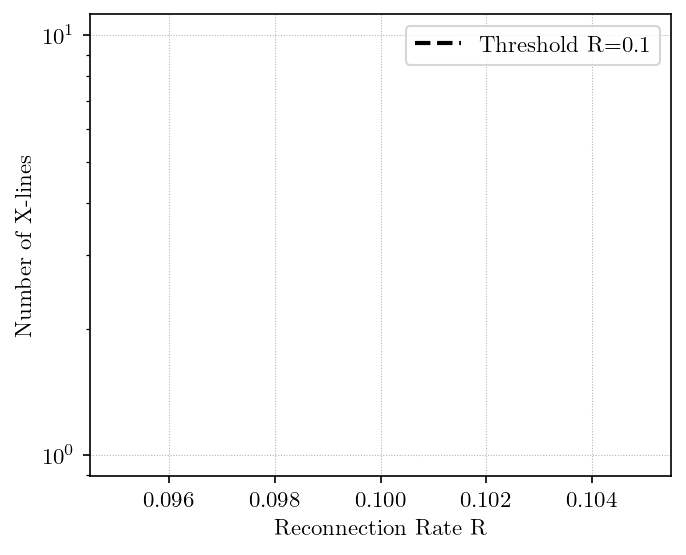

Processing /home/max/Temp/reconnection_rates_step_0002.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0002.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/2332628562.py:35: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


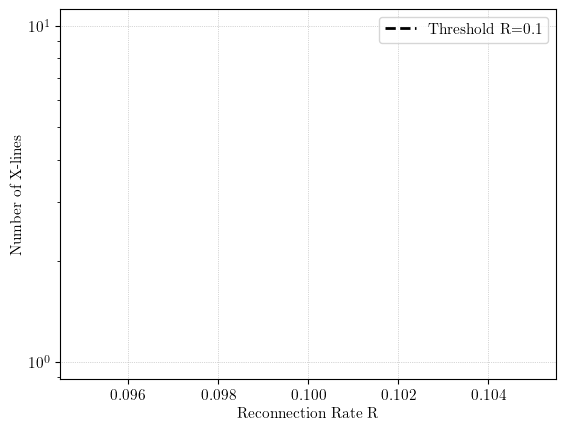

Processing /home/max/Temp/reconnection_rates_step_0003.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0003.txt"
  data = np.loadtxt(datapath)
/tmp/ipykernel_116133/2332628562.py:35: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


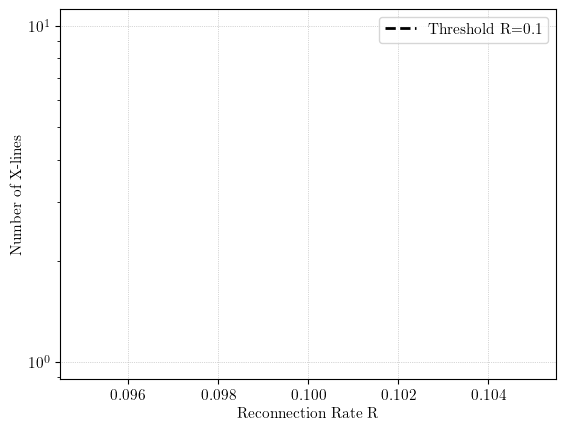

Processing /home/max/Temp/reconnection_rates_step_0004.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0004.txt"
  data = np.loadtxt(datapath)


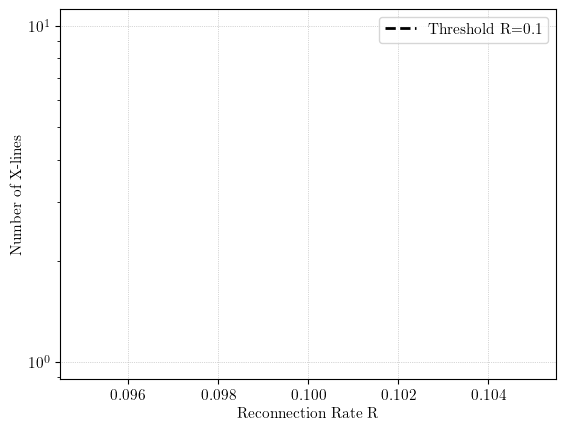

Processing /home/max/Temp/reconnection_rates_step_0005.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0005.txt"
  data = np.loadtxt(datapath)


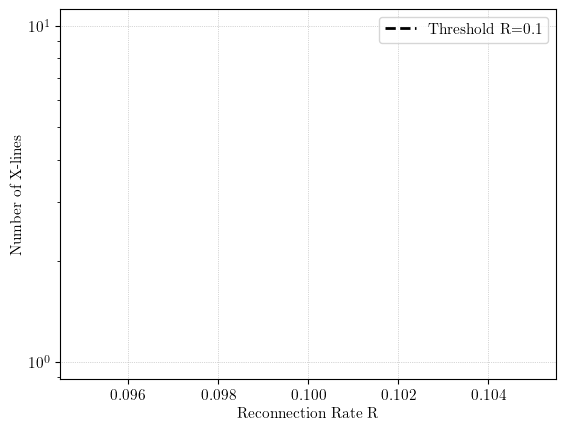

Processing /home/max/Temp/reconnection_rates_step_0006.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0006.txt"
  data = np.loadtxt(datapath)


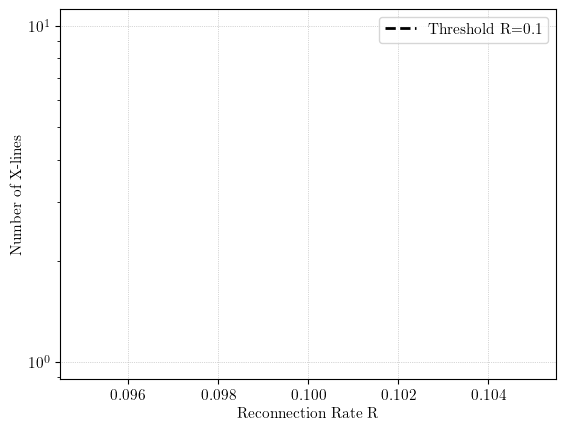

Processing /home/max/Temp/reconnection_rates_step_0007.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0007.txt"
  data = np.loadtxt(datapath)


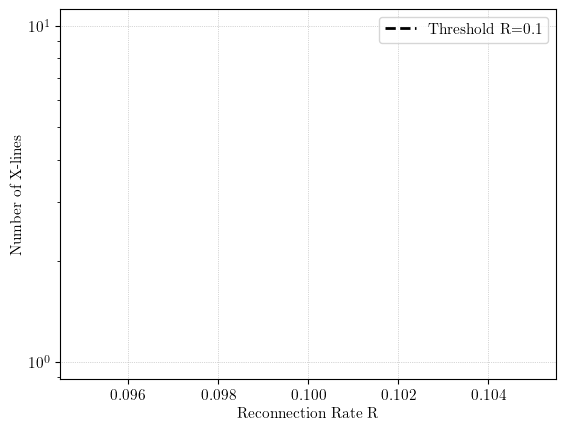

Processing /home/max/Temp/reconnection_rates_step_0008.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0008.txt"
  data = np.loadtxt(datapath)


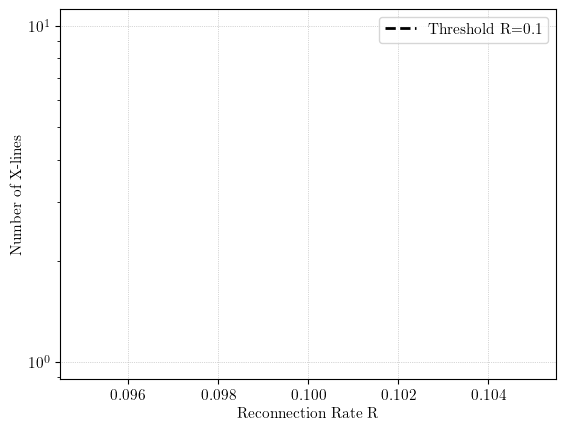

Processing /home/max/Temp/reconnection_rates_step_0009.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0009.txt"
  data = np.loadtxt(datapath)


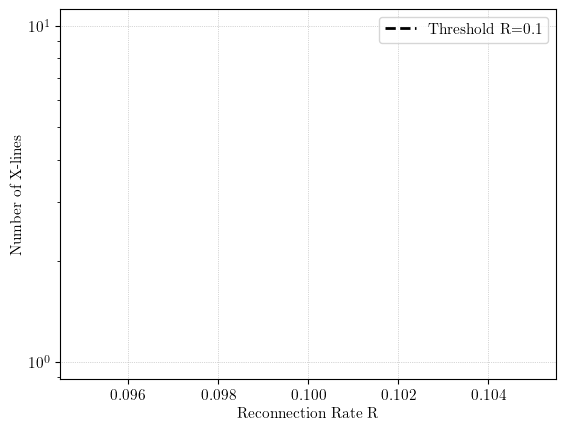

Processing /home/max/Temp/reconnection_rates_step_0010.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0010.txt"
  data = np.loadtxt(datapath)


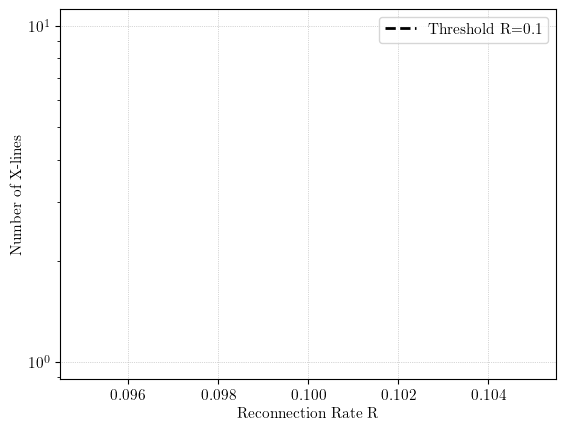

Processing /home/max/Temp/reconnection_rates_step_0011.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0011.txt"
  data = np.loadtxt(datapath)


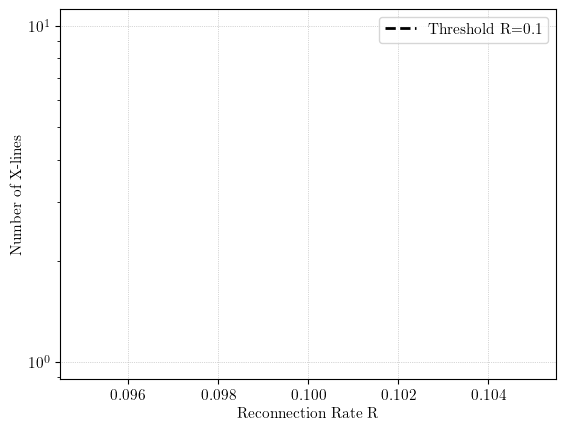

Processing /home/max/Temp/reconnection_rates_step_0012.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0012.txt"
  data = np.loadtxt(datapath)


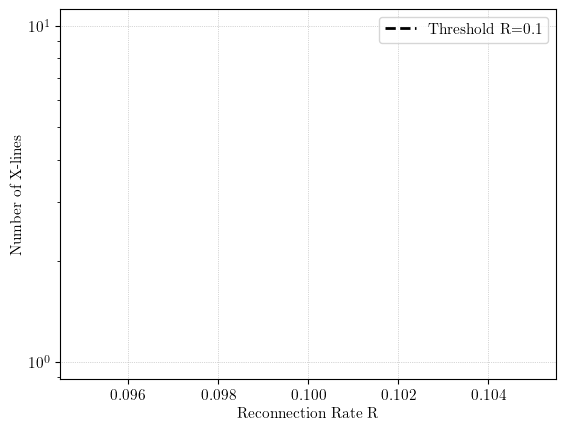

Processing /home/max/Temp/reconnection_rates_step_0013.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0013.txt"
  data = np.loadtxt(datapath)


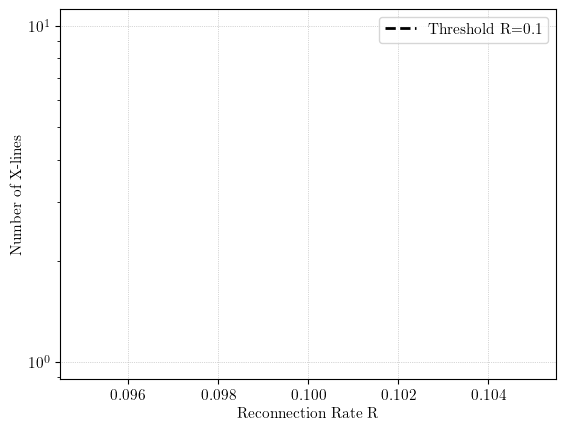

Processing /home/max/Temp/reconnection_rates_step_0014.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0014.txt"
  data = np.loadtxt(datapath)


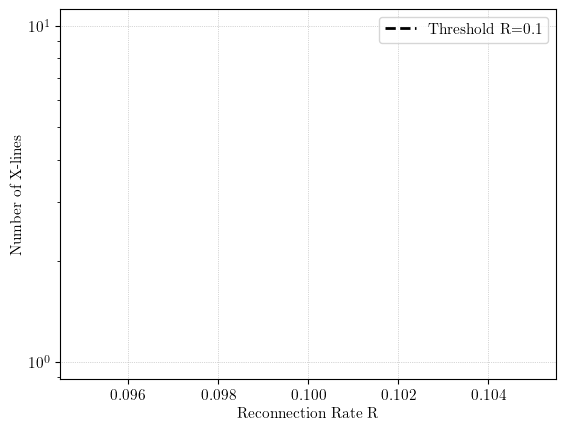

Processing /home/max/Temp/reconnection_rates_step_0015.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0015.txt"
  data = np.loadtxt(datapath)


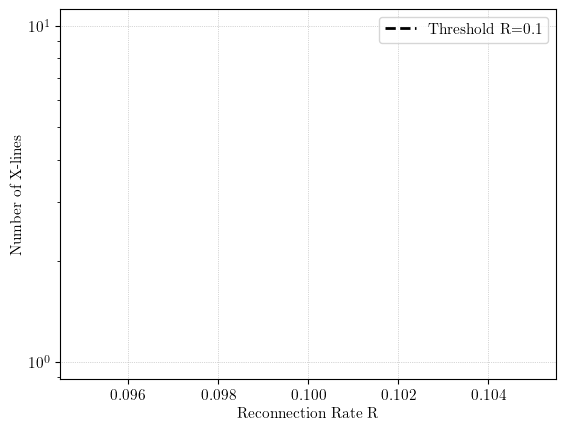

Processing /home/max/Temp/reconnection_rates_step_0016.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0016.txt"
  data = np.loadtxt(datapath)


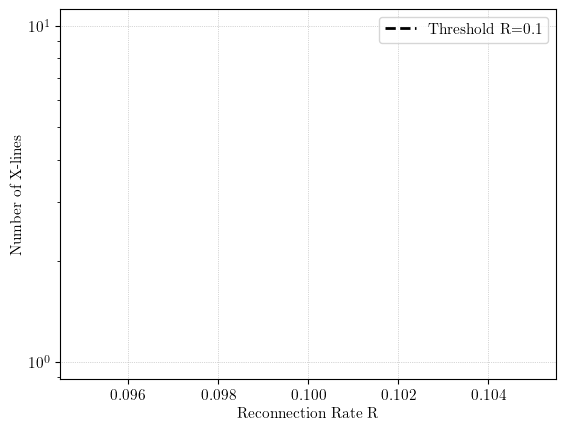

Processing /home/max/Temp/reconnection_rates_step_0017.txt


/tmp/ipykernel_116133/2332628562.py:4: UserWarning: loadtxt: input contained no data: "/home/max/Temp/reconnection_rates_step_0017.txt"
  data = np.loadtxt(datapath)


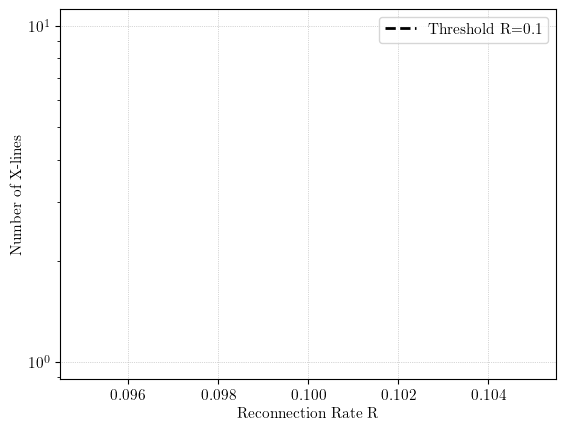

Processing /home/max/Temp/reconnection_rates_step_0018.txt


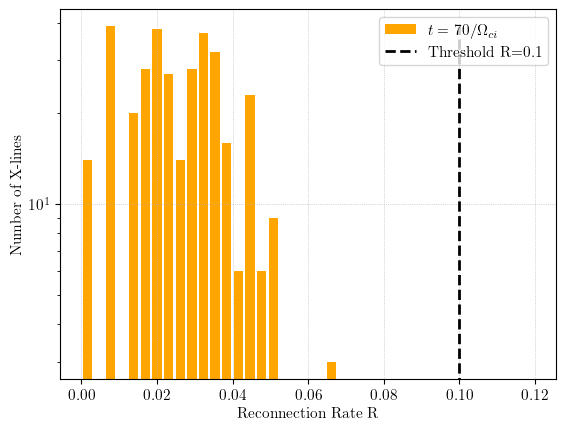

Processing /home/max/Temp/reconnection_rates_step_0019.txt


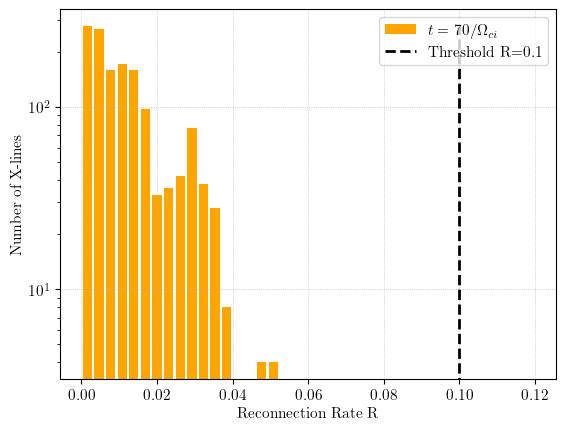

Processing /home/max/Temp/reconnection_rates_step_0020.txt


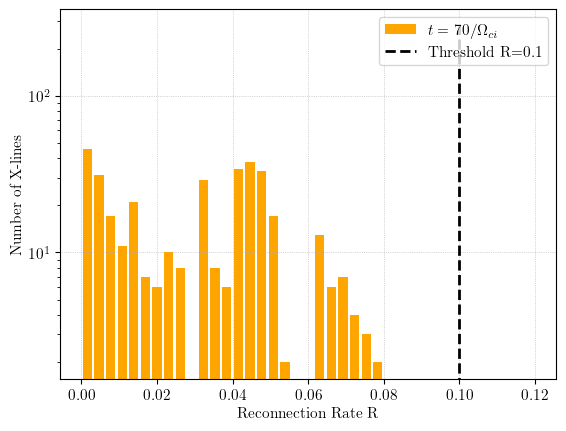

Processing /home/max/Temp/reconnection_rates_step_0021.txt


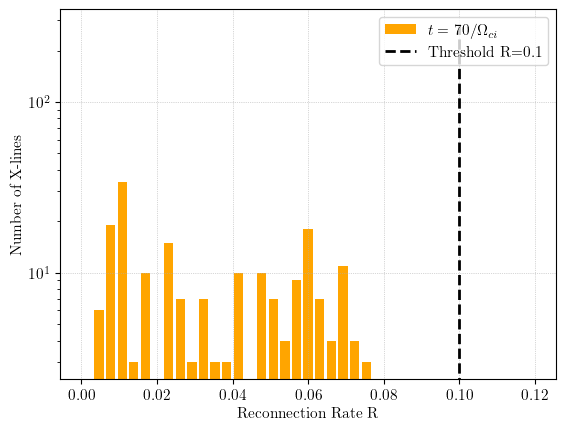

Processing /home/max/Temp/reconnection_rates_step_0022.txt


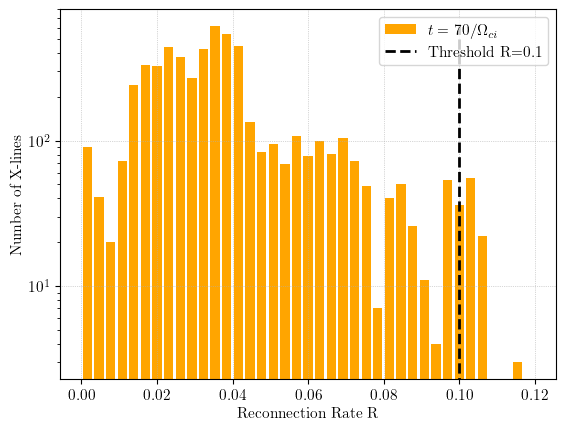

Processing /home/max/Temp/reconnection_rates_step_0023.txt


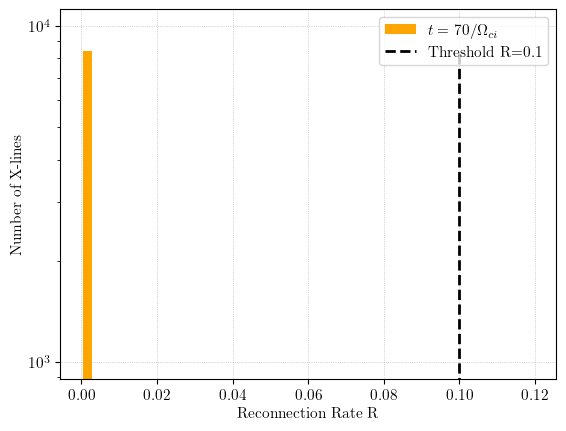

Processing /home/max/Temp/reconnection_rates_step_0024.txt


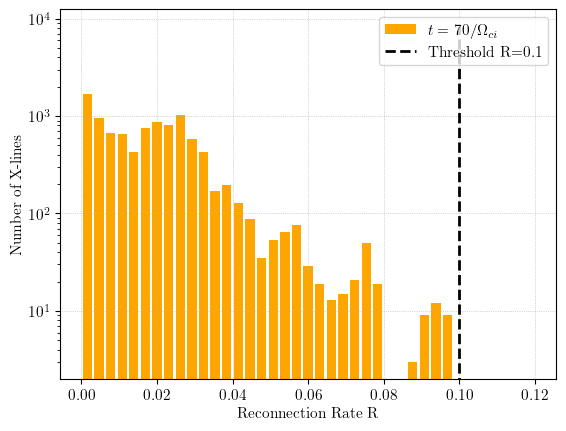

Processing /home/max/Temp/reconnection_rates_step_0025.txt


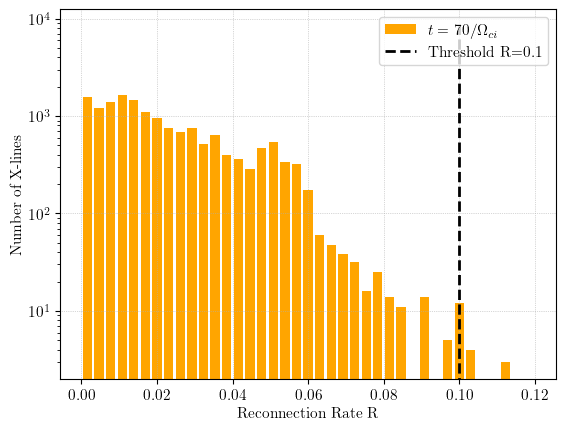

Processing /home/max/Temp/reconnection_rates_step_0026.txt


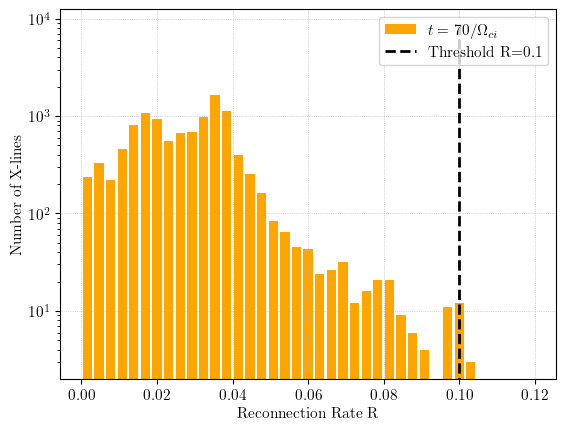

Processing /home/max/Temp/reconnection_rates_step_0027.txt


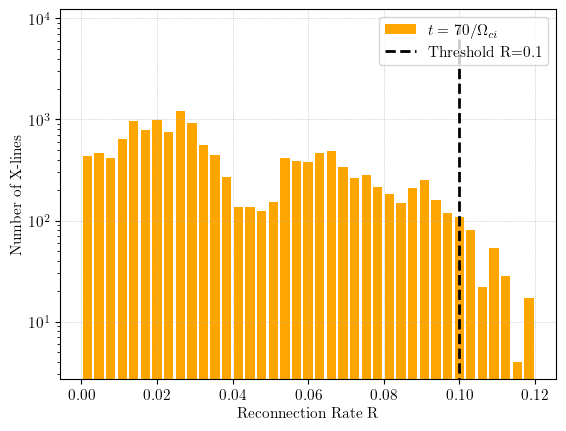

Processing /home/max/Temp/reconnection_rates_step_0028.txt


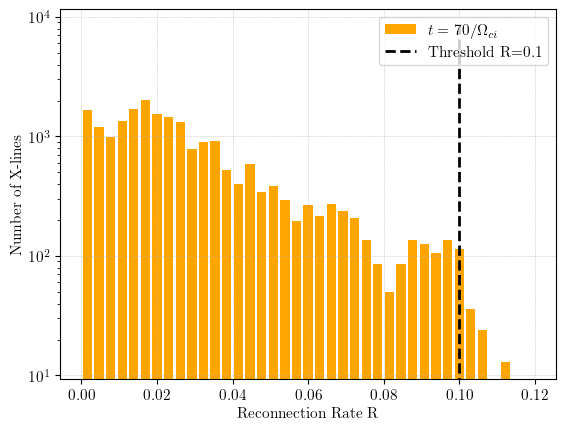

Processing /home/max/Temp/reconnection_rates_step_0029.txt


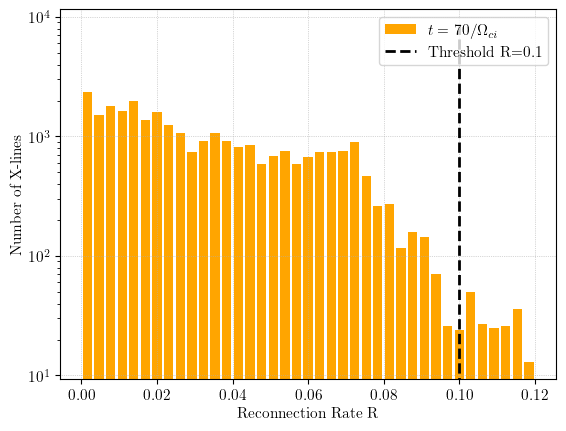

Processing /home/max/Temp/reconnection_rates_step_0030.txt


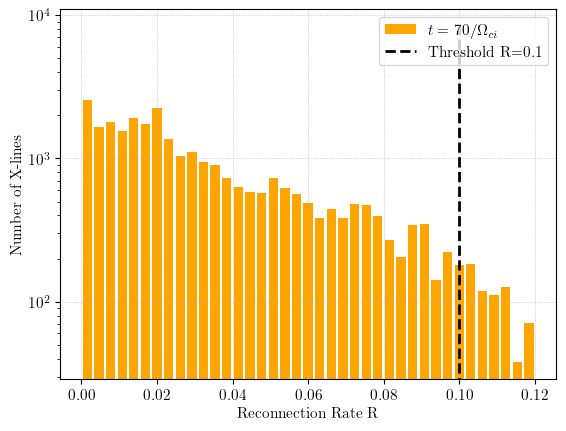

Processing /home/max/Temp/reconnection_rates_step_0031.txt


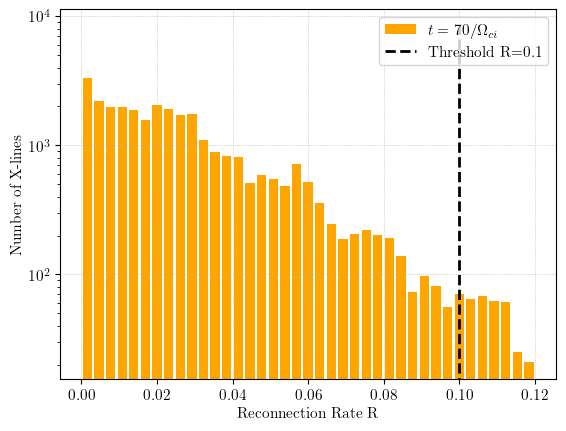

Processing /home/max/Temp/reconnection_rates_step_0032.txt


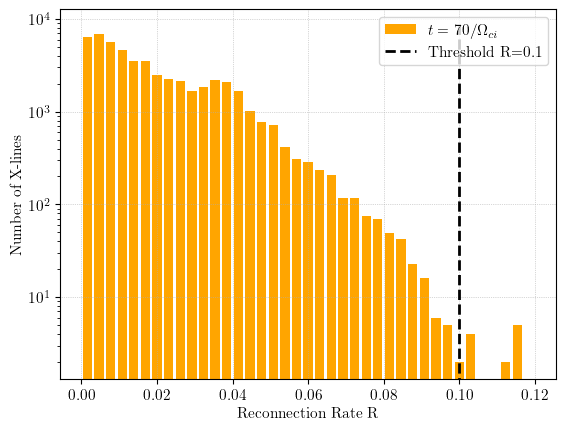

Processing /home/max/Temp/reconnection_rates_step_0033.txt


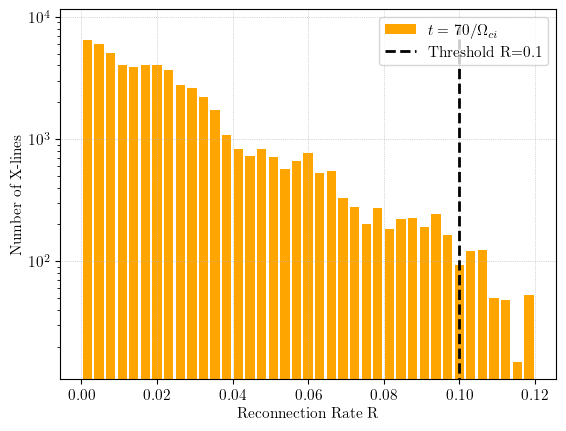

Processing /home/max/Temp/reconnection_rates_step_0034.txt


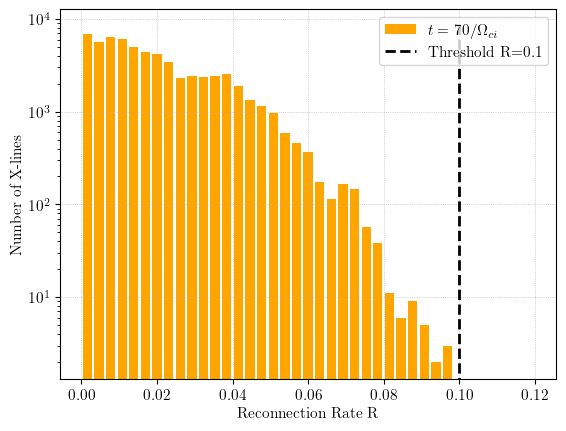

Processing /home/max/Temp/reconnection_rates_step_0035.txt


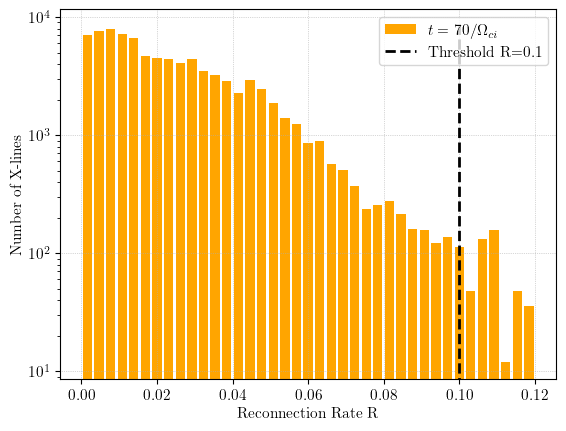

Processing /home/max/Temp/reconnection_rates_step_0036.txt


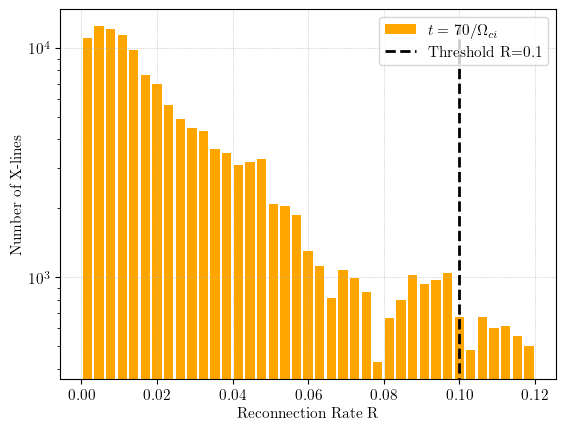

Processing /home/max/Temp/reconnection_rates_step_0037.txt


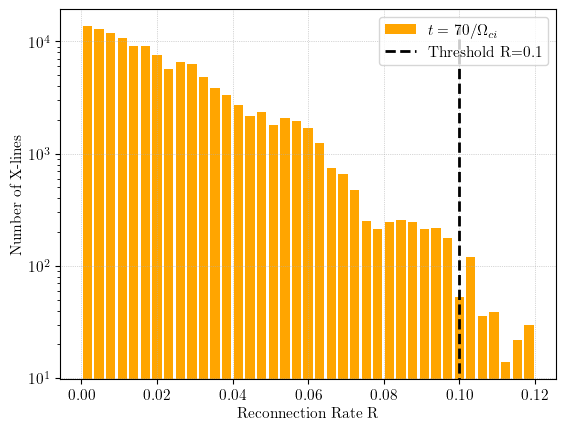

Processing /home/max/Temp/reconnection_rates_step_0038.txt


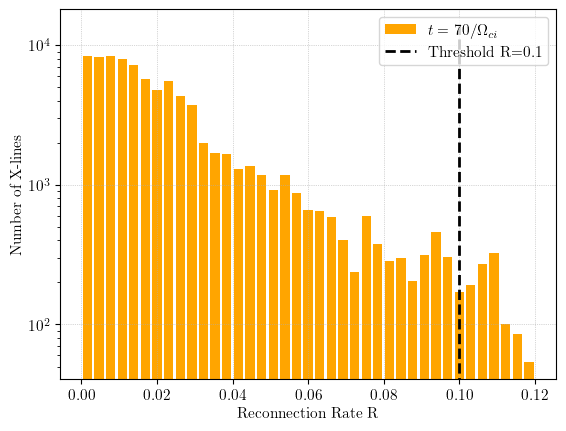

Processing /home/max/Temp/reconnection_rates_step_0039.txt


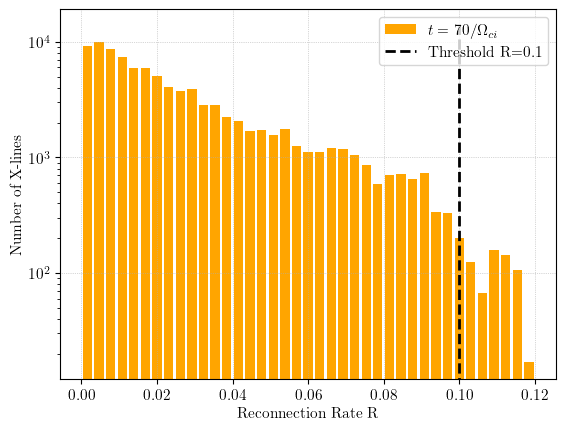

Processing /home/max/Temp/reconnection_rates_step_0040.txt


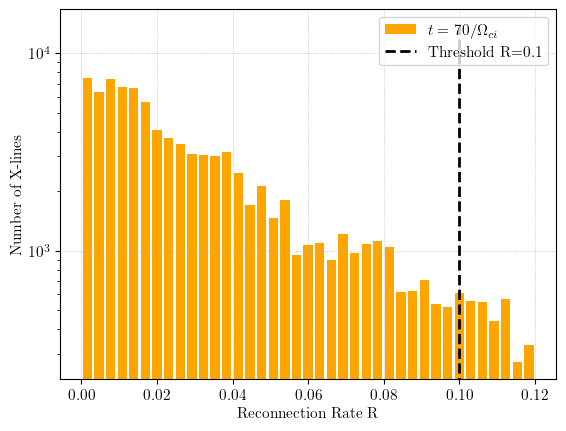

Processing /home/max/Temp/reconnection_rates_step_0041.txt


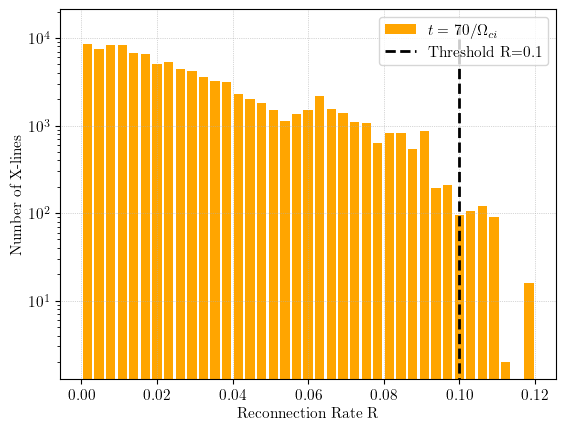

Processing /home/max/Temp/reconnection_rates_step_0042.txt


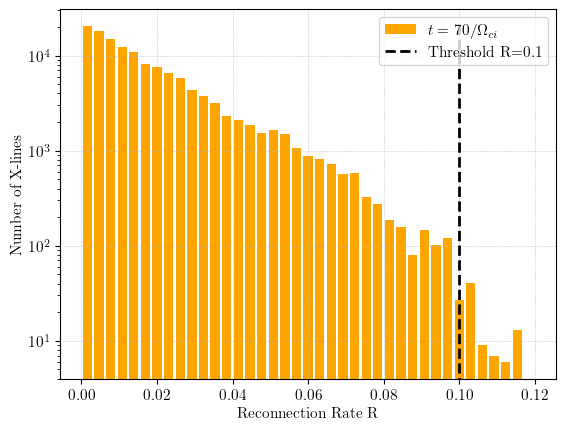

Processing /home/max/Temp/reconnection_rates_step_0043.txt


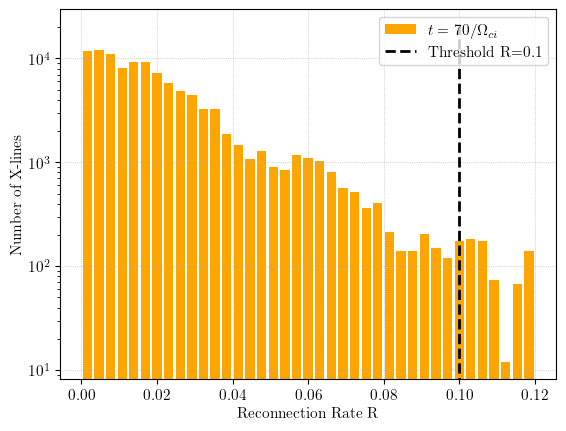

Processing /home/max/Temp/reconnection_rates_step_0044.txt


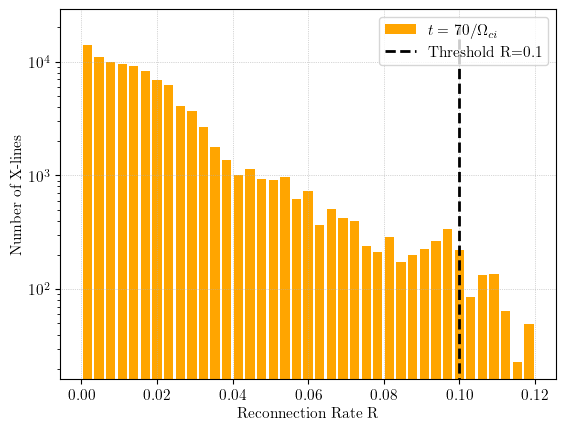

Processing /home/max/Temp/reconnection_rates_step_0045.txt


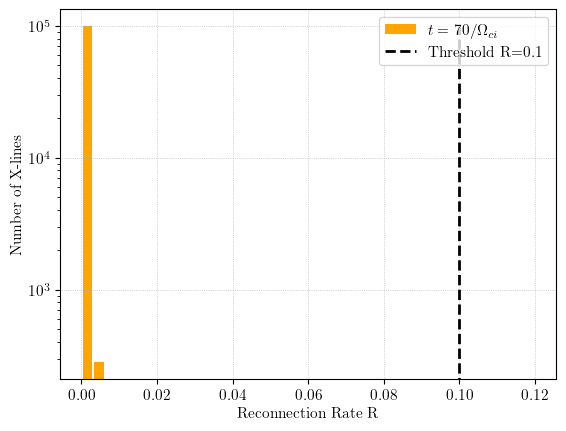

Processing /home/max/Temp/reconnection_rates_step_0046.txt


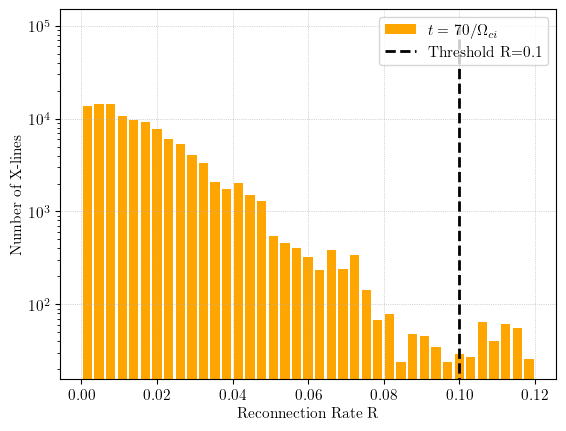

Processing /home/max/Temp/reconnection_rates_step_0047.txt


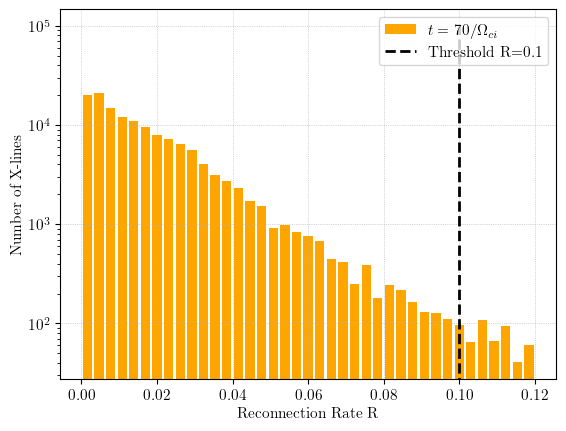

Processing /home/max/Temp/reconnection_rates_step_0048.txt


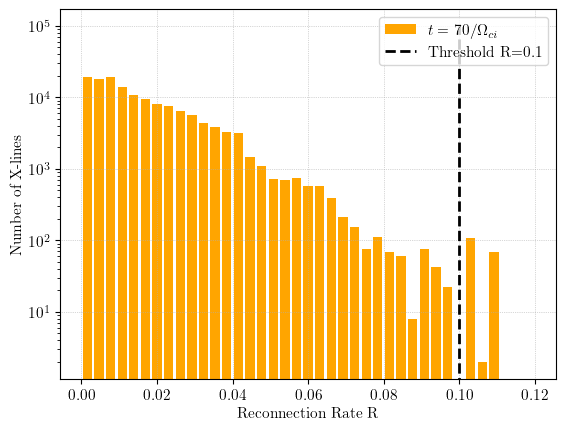

Processing /home/max/Temp/reconnection_rates_step_0049.txt


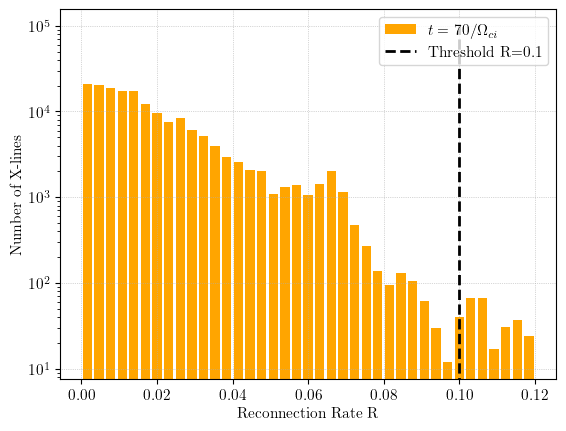

Processing /home/max/Temp/reconnection_rates_step_0050.txt


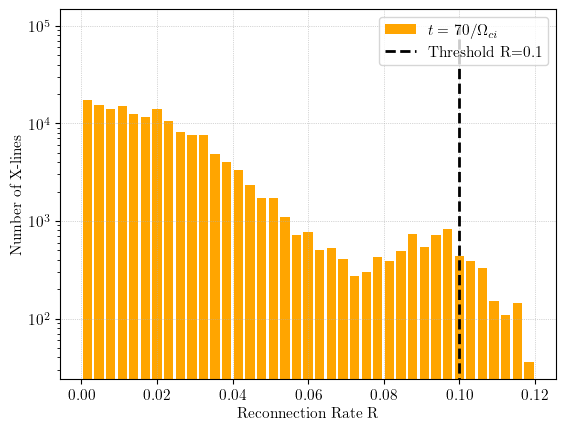

Processing /home/max/Temp/reconnection_rates_step_0051.txt


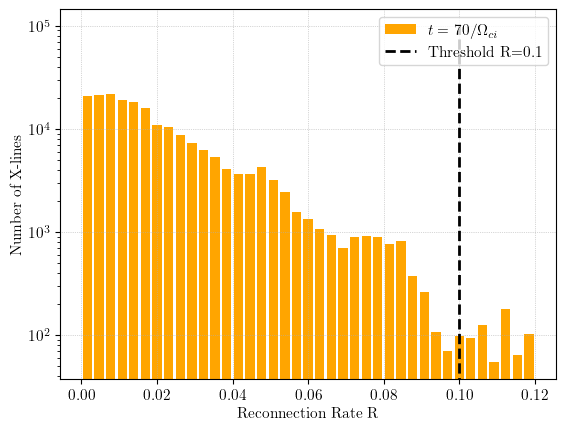

Processing /home/max/Temp/reconnection_rates_step_0052.txt


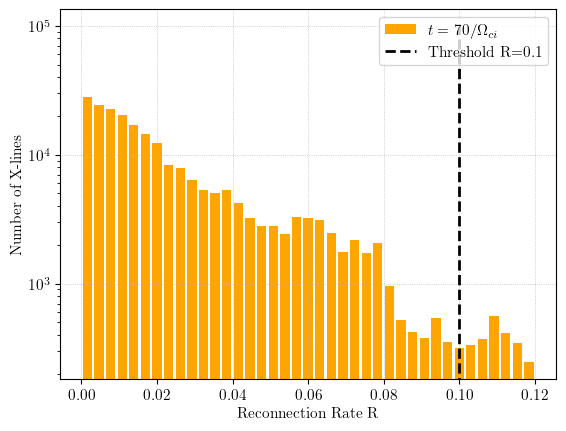

Processing /home/max/Temp/reconnection_rates_step_0053.txt


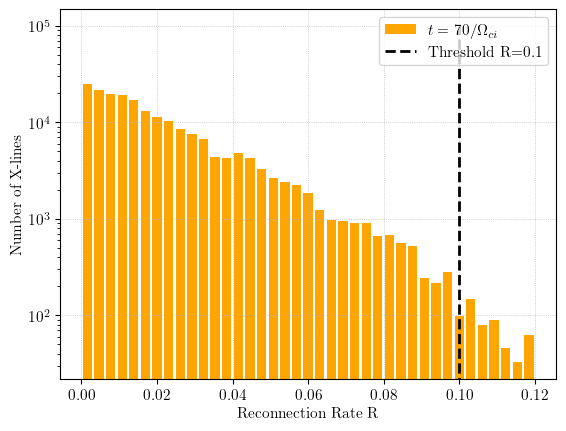

Processing /home/max/Temp/reconnection_rates_step_0054.txt


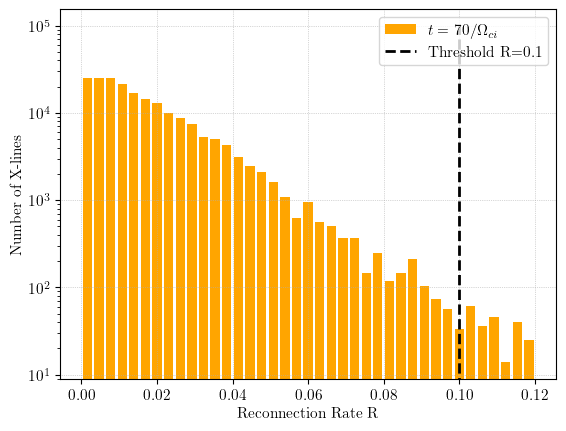

Processing /home/max/Temp/reconnection_rates_step_0055.txt


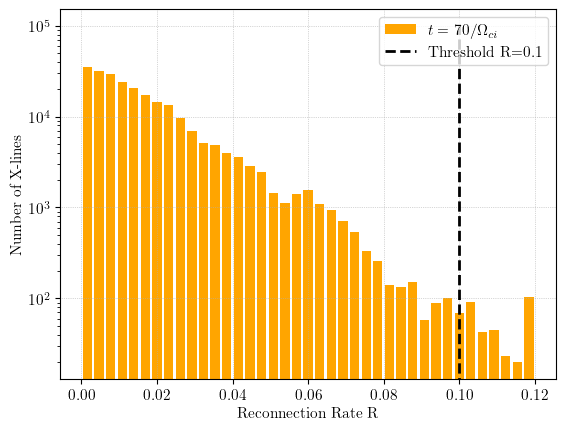

Processing /home/max/Temp/reconnection_rates_step_0056.txt


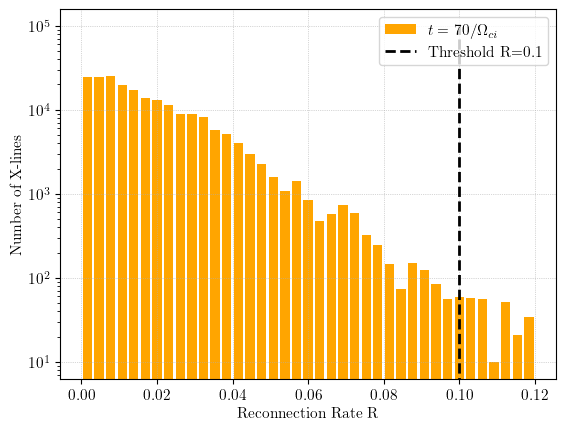

Processing /home/max/Temp/reconnection_rates_step_0057.txt


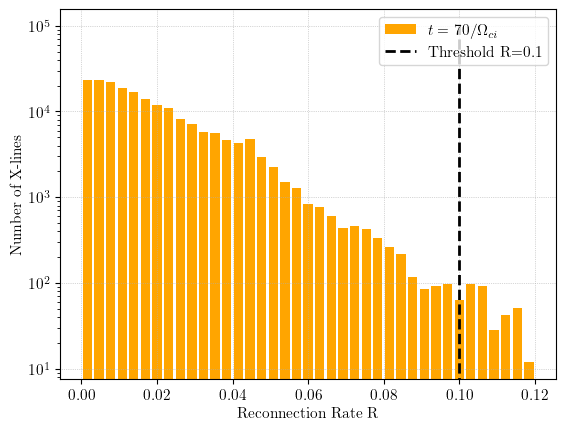

Processing /home/max/Temp/reconnection_rates_step_0058.txt


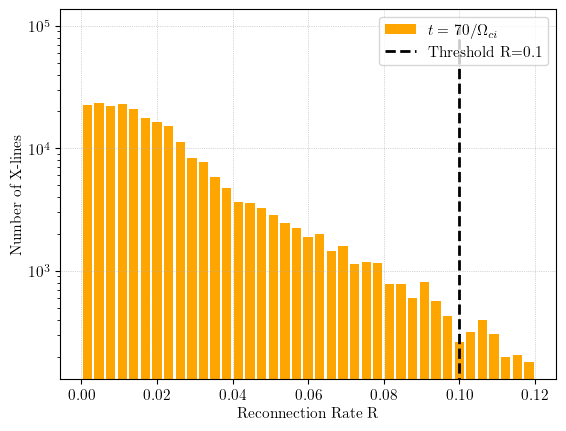

Processing /home/max/Temp/reconnection_rates_step_0059.txt


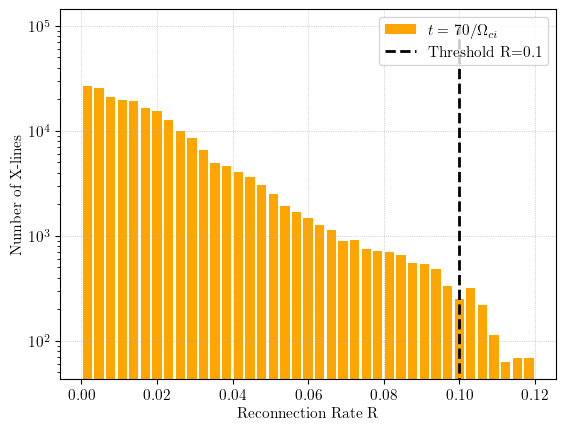

Processing /home/max/Temp/reconnection_rates_step_0060.txt


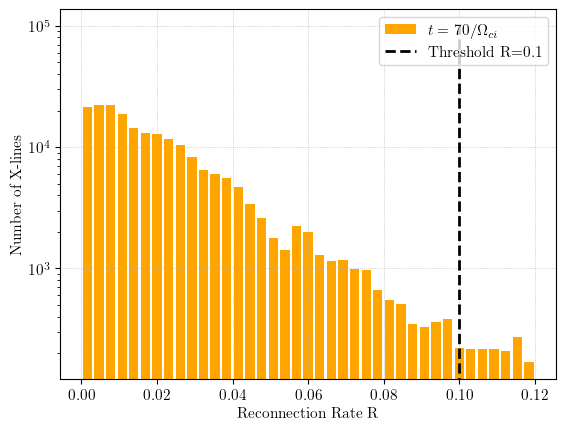

Processing /home/max/Temp/reconnection_rates_step_0061.txt


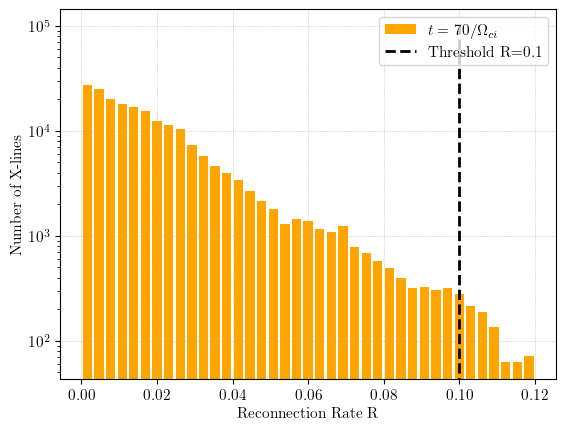

Processing /home/max/Temp/reconnection_rates_step_0062.txt


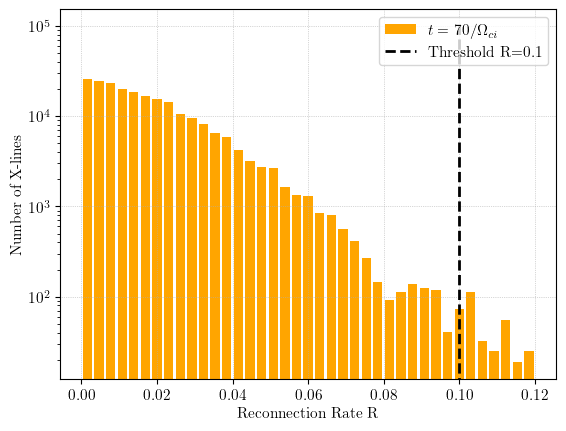

Processing /home/max/Temp/reconnection_rates_step_0063.txt


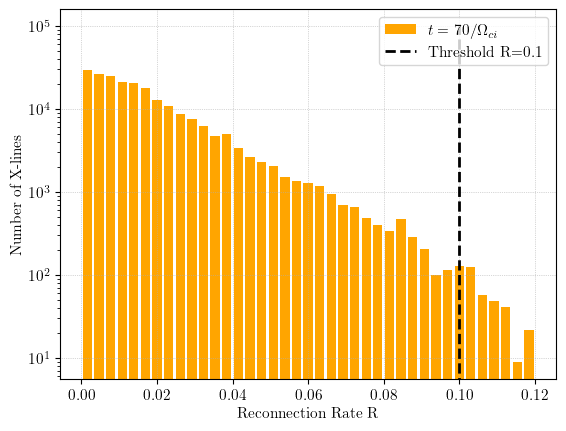

Processing /home/max/Temp/reconnection_rates_step_0064.txt


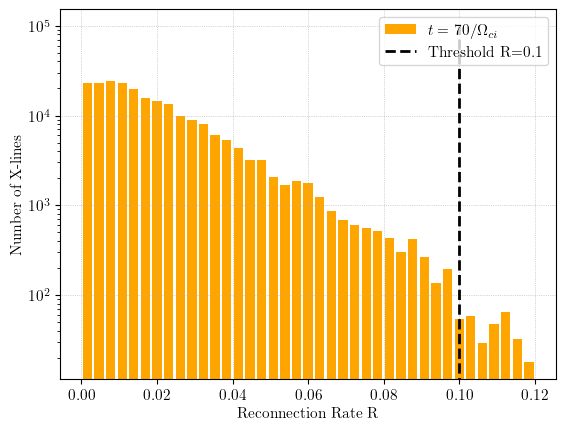

Processing /home/max/Temp/reconnection_rates_step_0065.txt


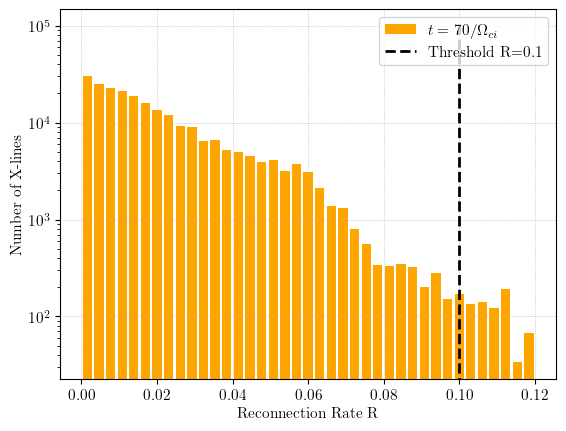

Processing /home/max/Temp/reconnection_rates_step_0066.txt


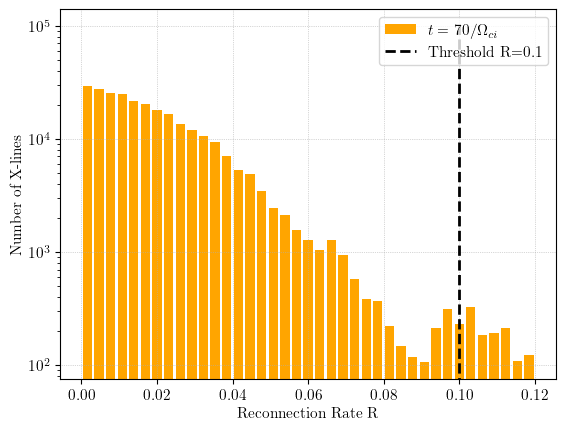

Processing /home/max/Temp/reconnection_rates_step_0067.txt


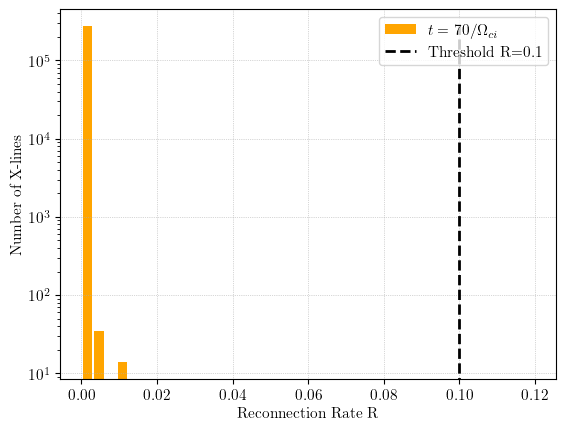

Processing /home/max/Temp/reconnection_rates_step_0068.txt


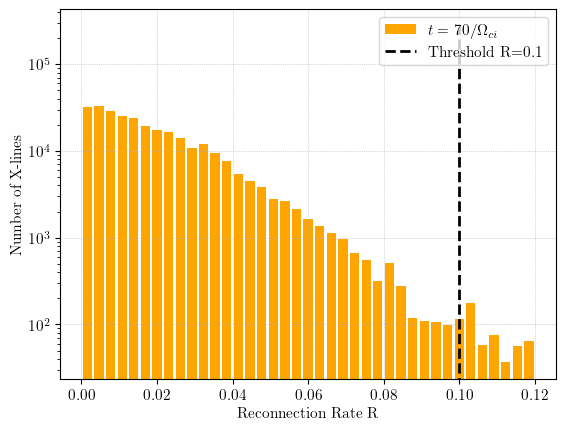

Processing /home/max/Temp/reconnection_rates_step_0069.txt


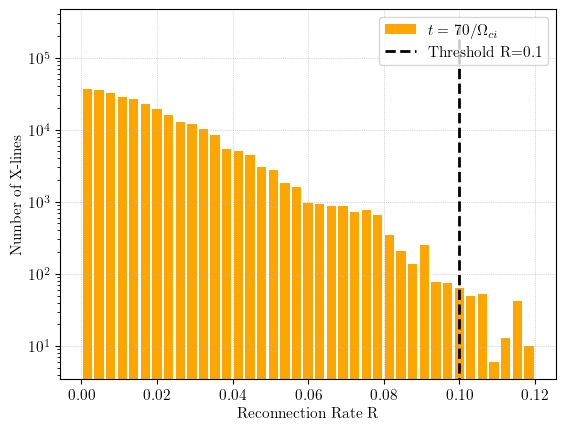

Processing /home/max/Temp/reconnection_rates_step_0070.txt


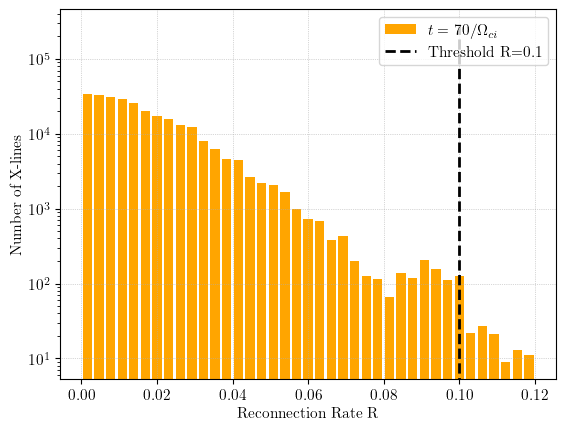

Processing /home/max/Temp/reconnection_rates_step_0071.txt


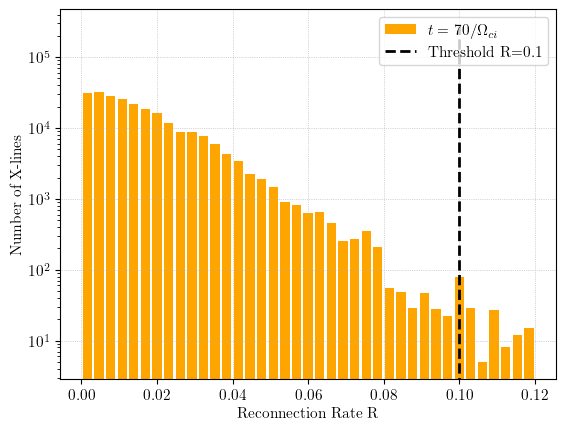

Processing /home/max/Temp/reconnection_rates_step_0072.txt


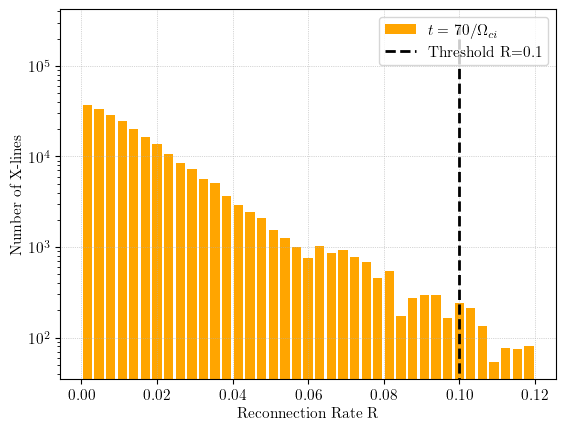

Processing /home/max/Temp/reconnection_rates_step_0073.txt


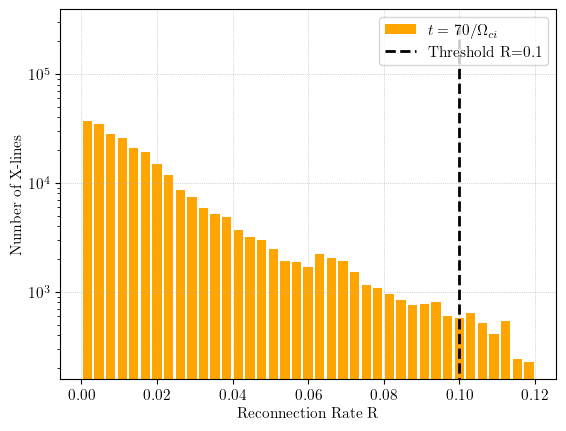

Processing /home/max/Temp/reconnection_rates_step_0074.txt


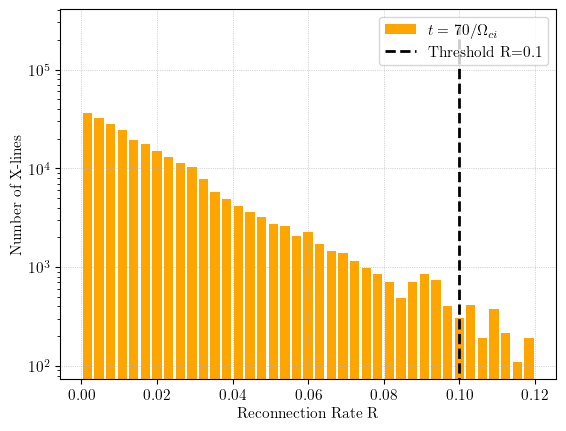

Processing /home/max/Temp/reconnection_rates_step_0075.txt


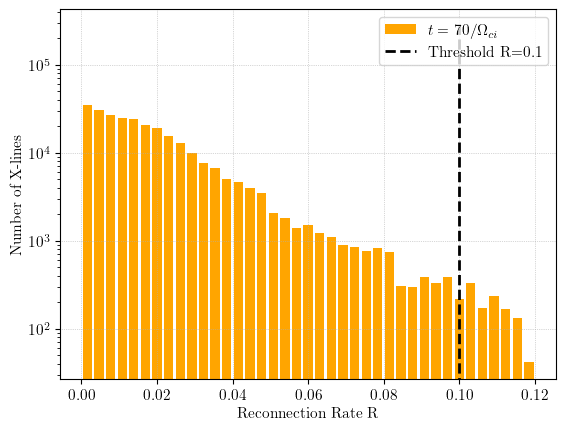

Processing /home/max/Temp/reconnection_rates_step_0076.txt


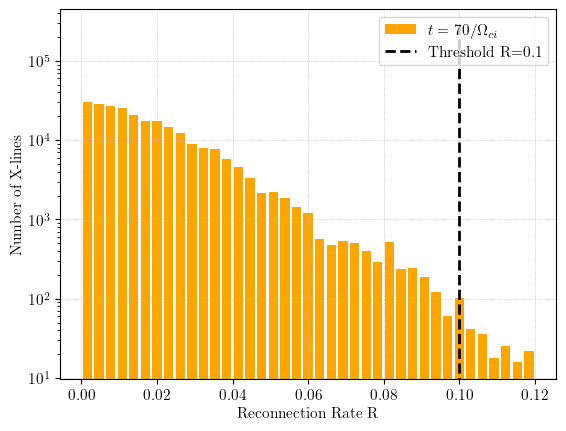

Processing /home/max/Temp/reconnection_rates_step_0077.txt


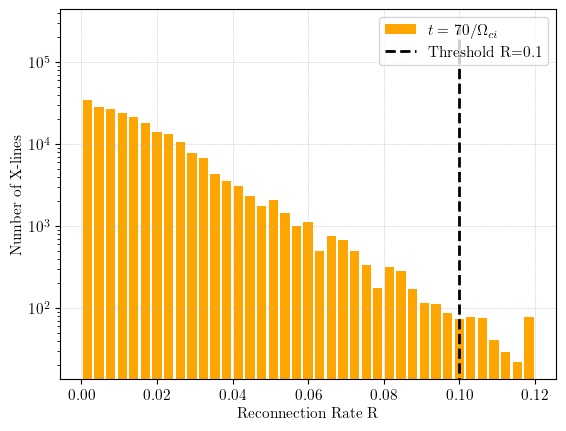

Processing /home/max/Temp/reconnection_rates_step_0078.txt


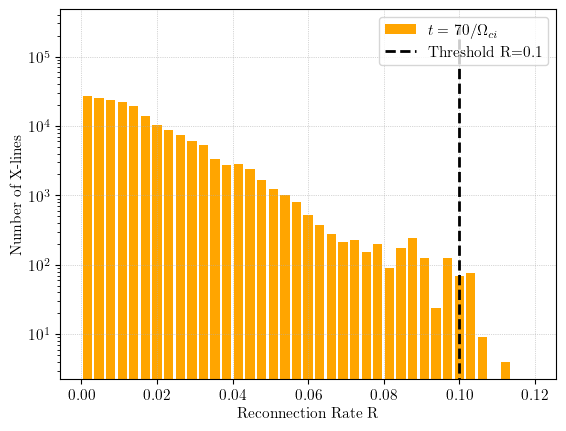

Processing /home/max/Temp/reconnection_rates_step_0079.txt


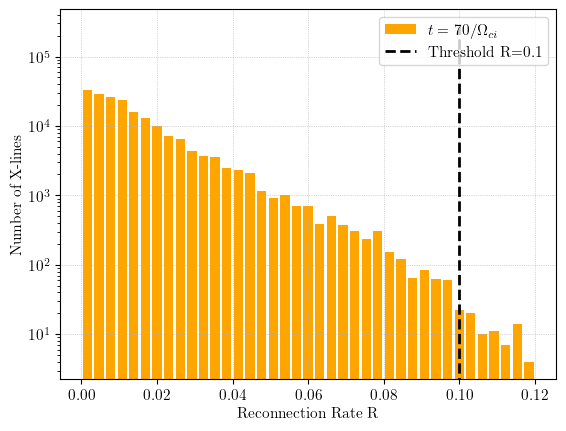

Processing /home/max/Temp/reconnection_rates_step_0080.txt


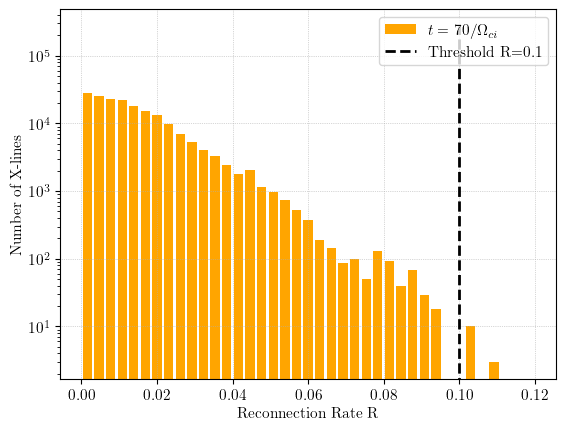

Processing /home/max/Temp/reconnection_rates_step_0081.txt


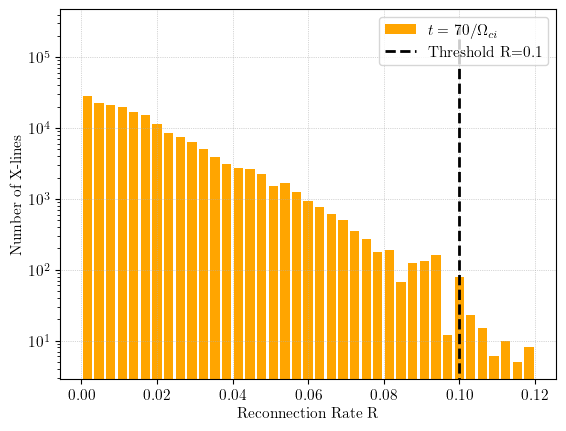

Processing /home/max/Temp/reconnection_rates_step_0082.txt


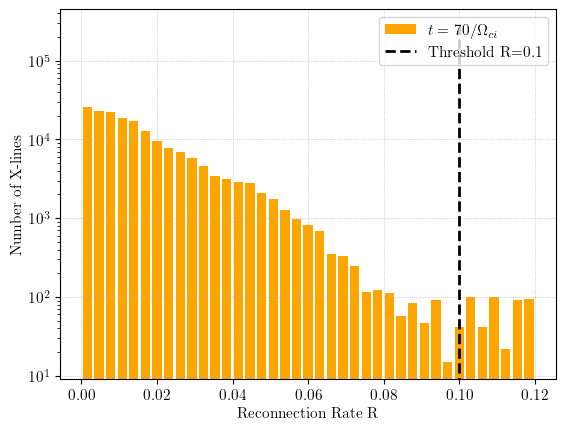

Processing /home/max/Temp/reconnection_rates_step_0083.txt


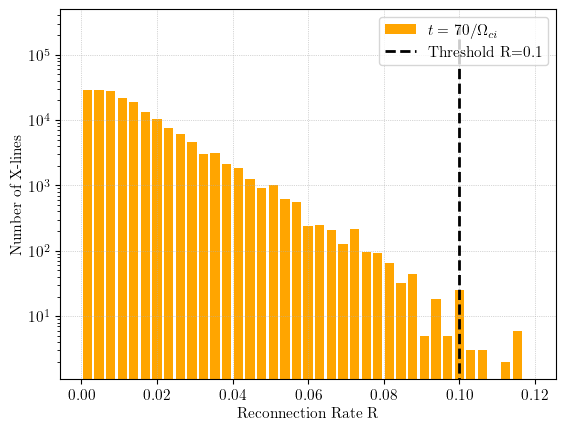

Processing /home/max/Temp/reconnection_rates_step_0084.txt


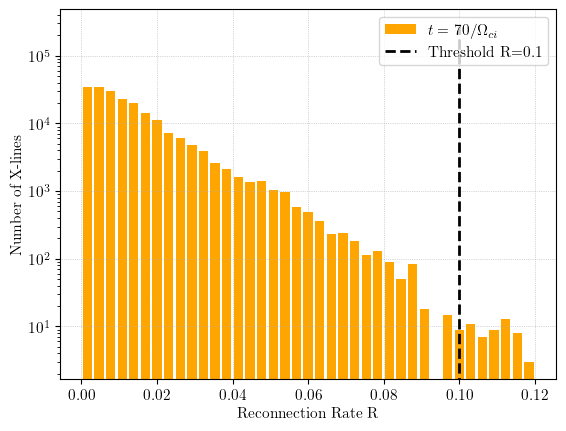

Processing /home/max/Temp/reconnection_rates_step_0085.txt


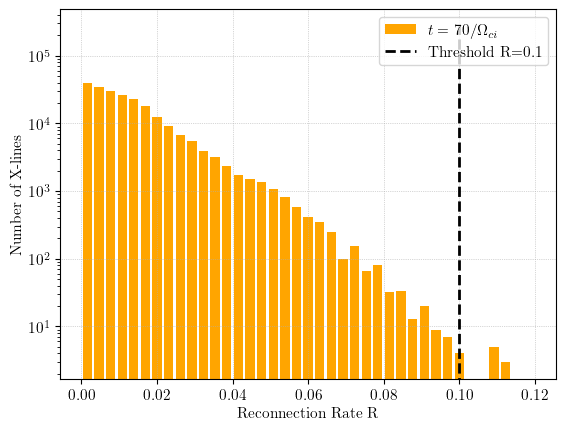

Processing /home/max/Temp/reconnection_rates_step_0086.txt


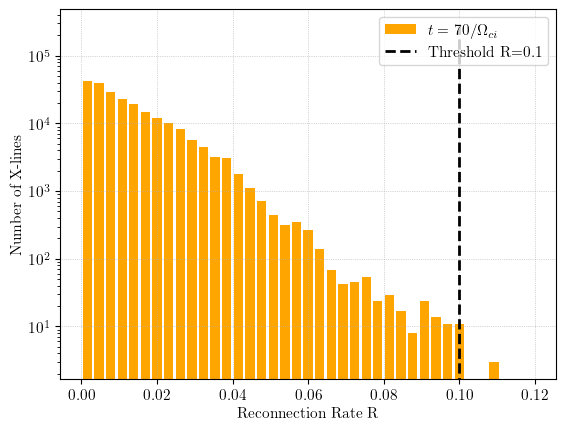

Processing /home/max/Temp/reconnection_rates_step_0087.txt


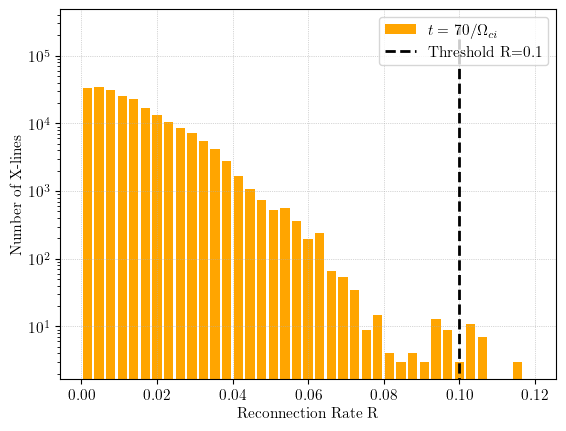

Processing /home/max/Temp/reconnection_rates_step_0088.txt


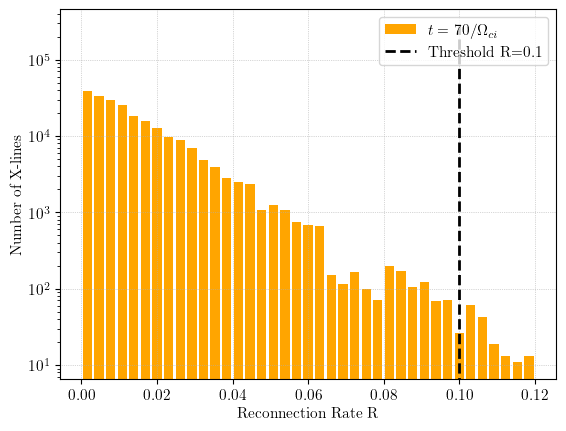

Processing /home/max/Temp/reconnection_rates_step_0089.txt


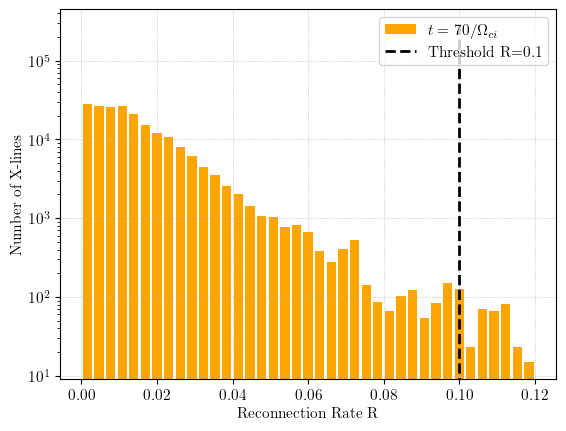

Processing /home/max/Temp/reconnection_rates_step_0090.txt


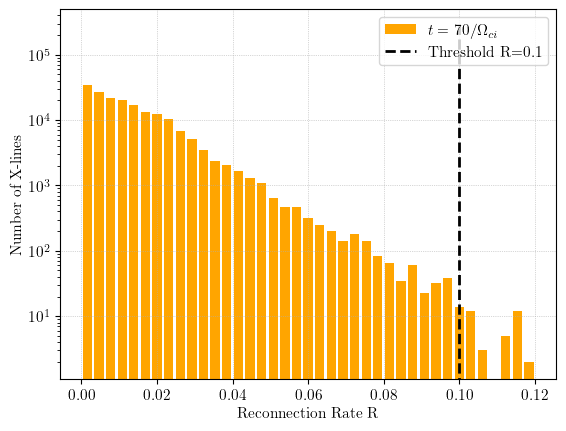

Processing /home/max/Temp/reconnection_rates_step_0091.txt


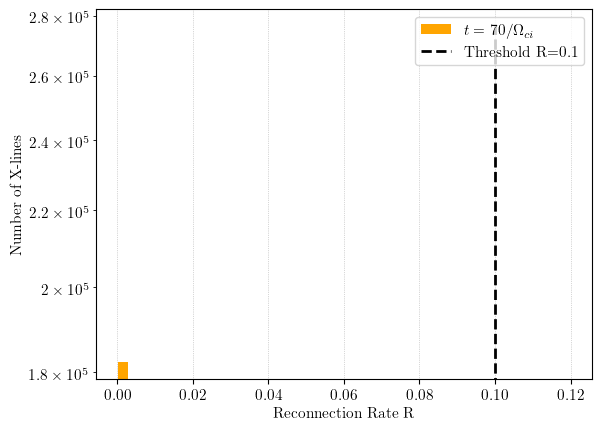

Processing /home/max/Temp/reconnection_rates_step_0092.txt


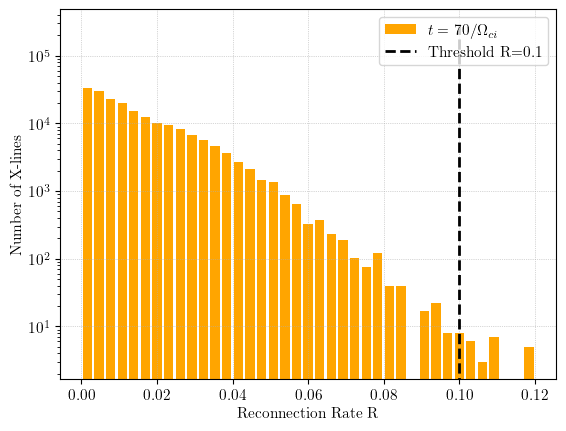

Processing /home/max/Temp/reconnection_rates_step_0093.txt


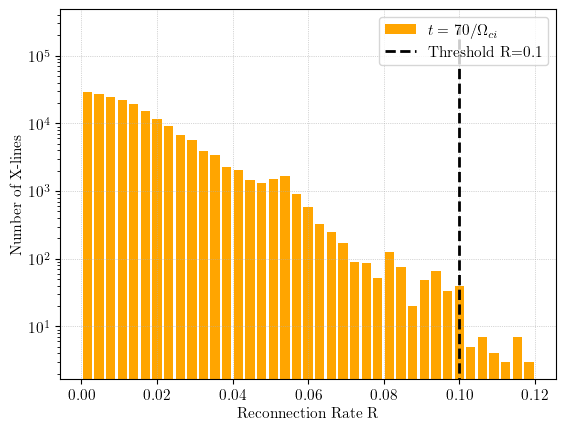

Processing /home/max/Temp/reconnection_rates_step_0094.txt


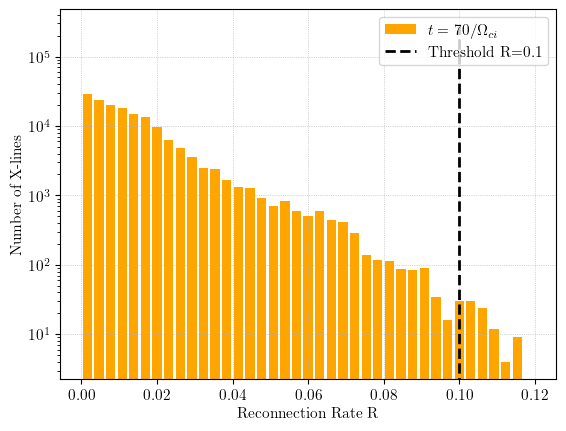

Processing /home/max/Temp/reconnection_rates_step_0095.txt


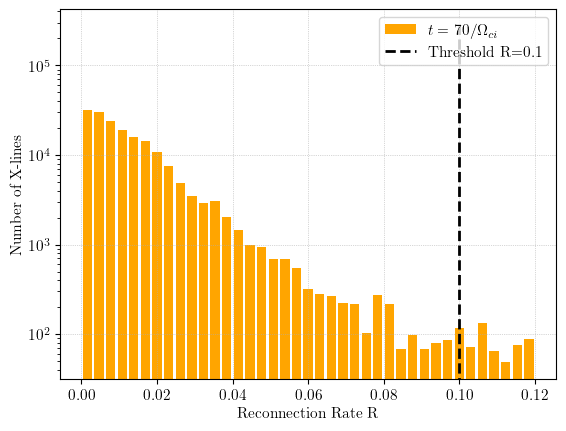

Processing /home/max/Temp/reconnection_rates_step_0096.txt


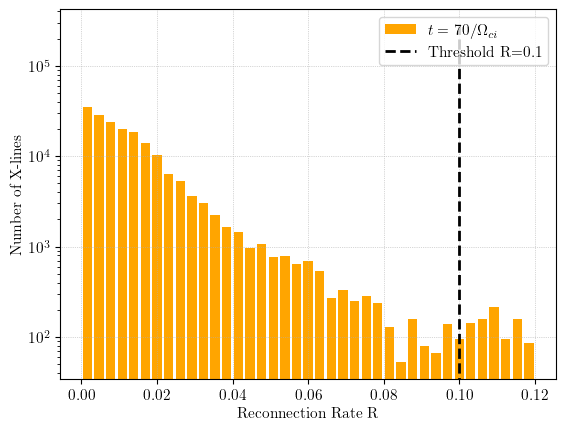

Processing /home/max/Temp/reconnection_rates_step_0097.txt


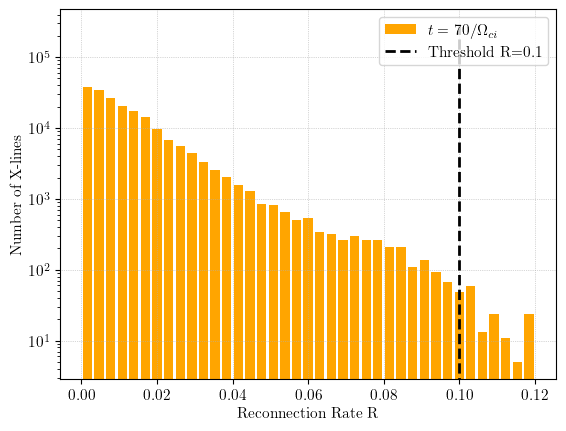

Processing /home/max/Temp/reconnection_rates_step_0098.txt


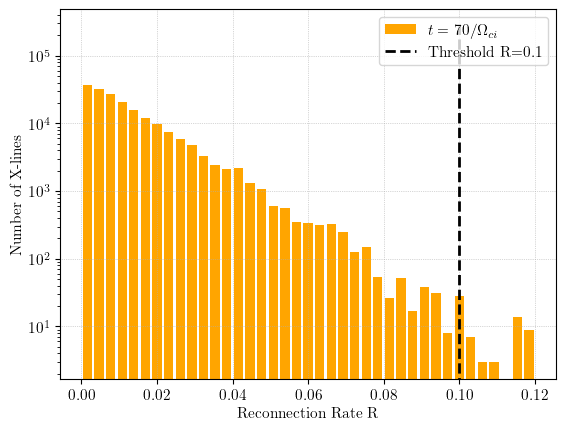

Processing /home/max/Temp/reconnection_rates_step_0099.txt


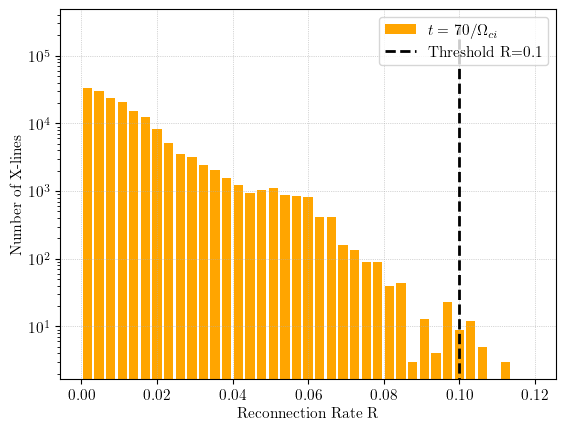

Processing /home/max/Temp/reconnection_rates_step_0100.txt


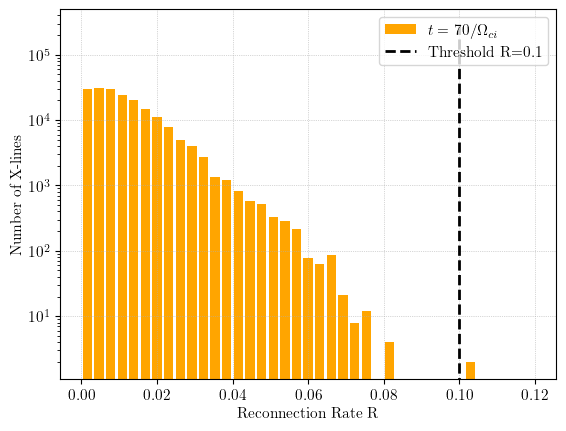

Processing /home/max/Temp/reconnection_rates_step_0101.txt


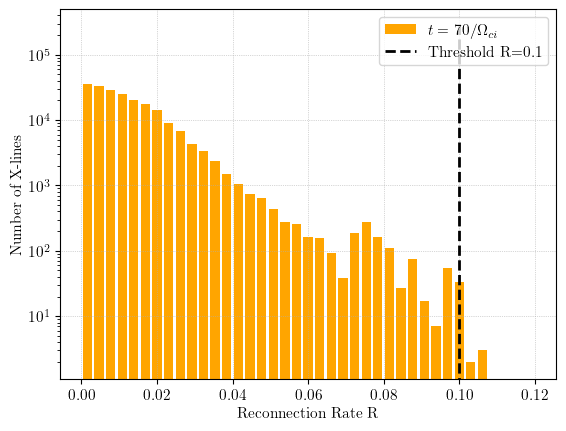

Processing /home/max/Temp/reconnection_rates_step_0102.txt


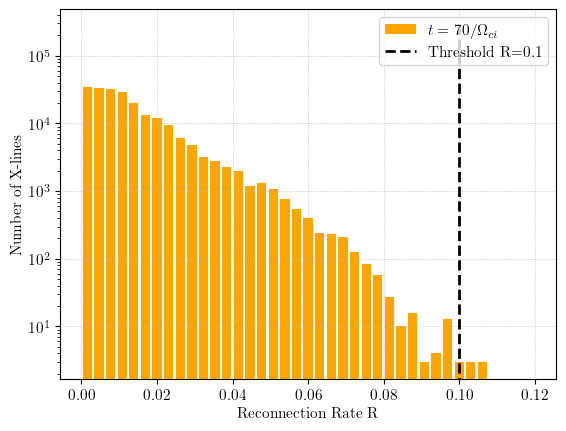

Processing /home/max/Temp/reconnection_rates_step_0103.txt


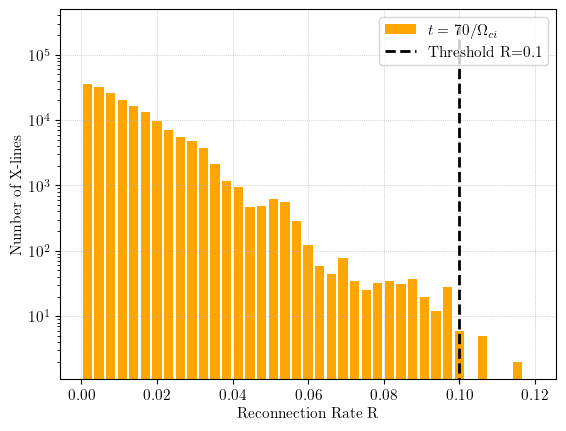

Processing /home/max/Temp/reconnection_rates_step_0104.txt


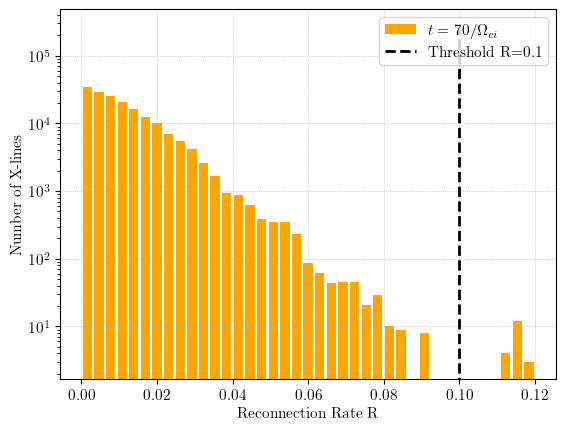

Processing /home/max/Temp/reconnection_rates_step_0105.txt


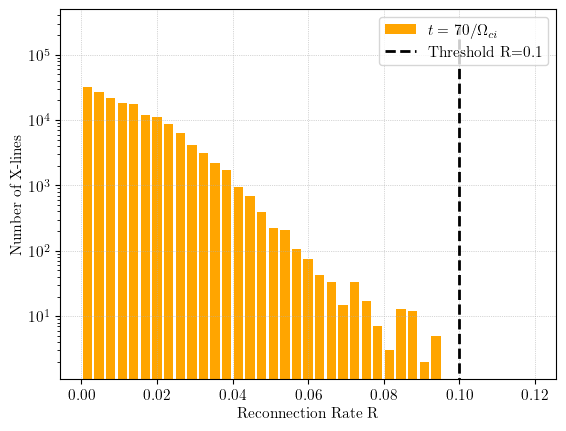

Processing /home/max/Temp/reconnection_rates_step_0106.txt


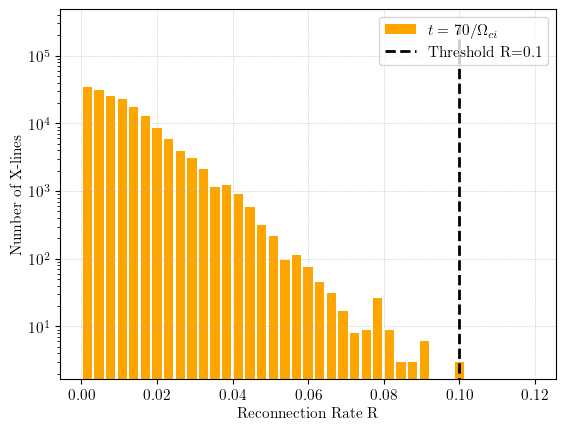

Processing /home/max/Temp/reconnection_rates_step_0107.txt


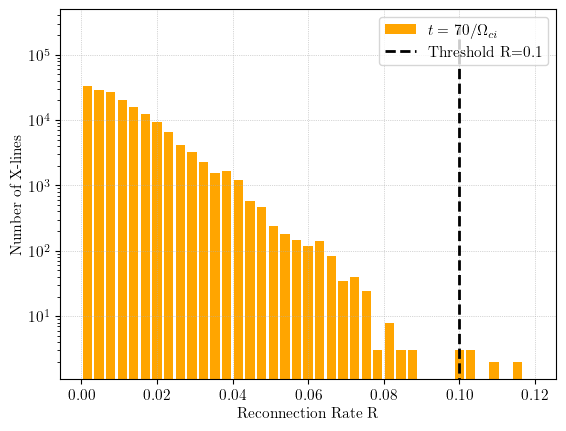

Processing /home/max/Temp/reconnection_rates_step_0108.txt


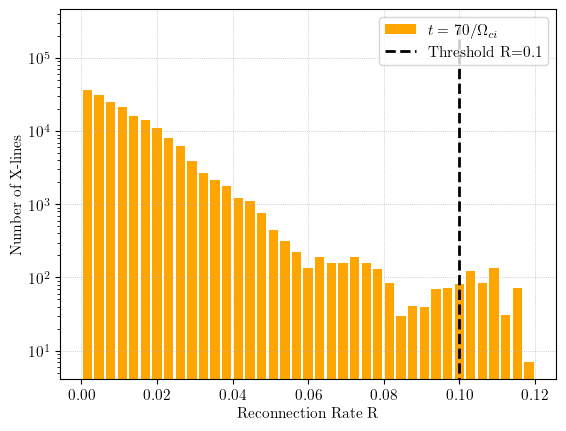

Processing /home/max/Temp/reconnection_rates_step_0109.txt


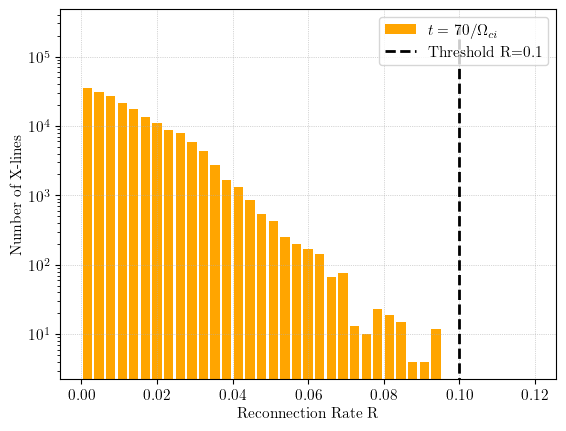

Processing /home/max/Temp/reconnection_rates_step_0110.txt


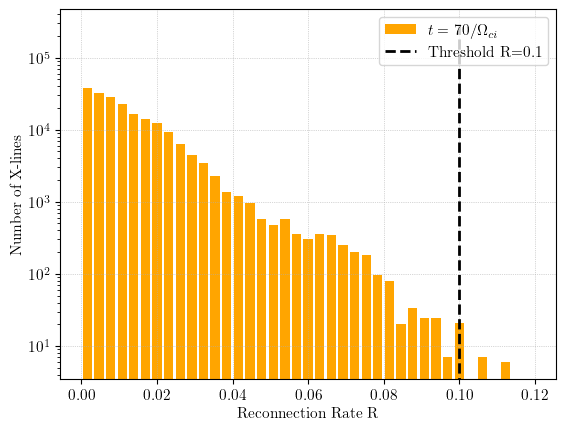

Processing /home/max/Temp/reconnection_rates_step_0111.txt


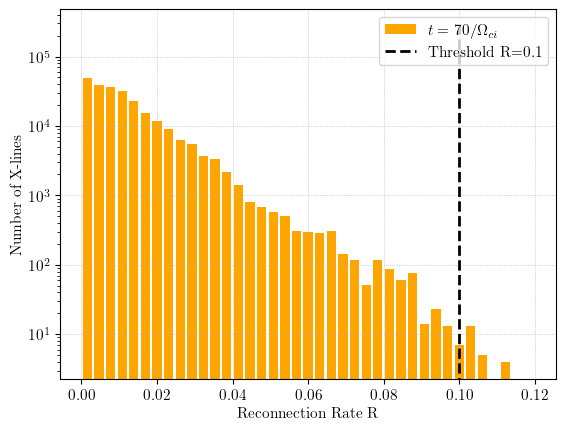

Processing /home/max/Temp/reconnection_rates_step_0112.txt


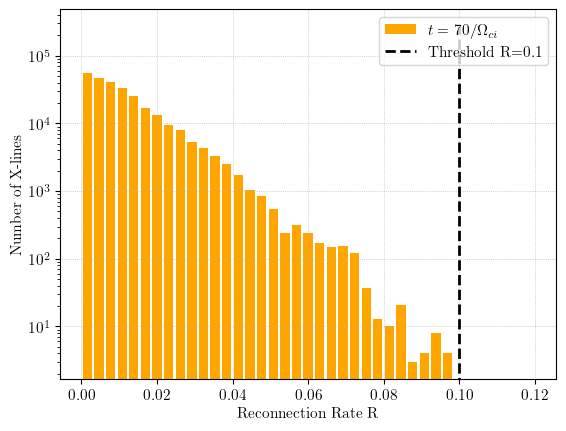

Processing /home/max/Temp/reconnection_rates_step_0113.txt


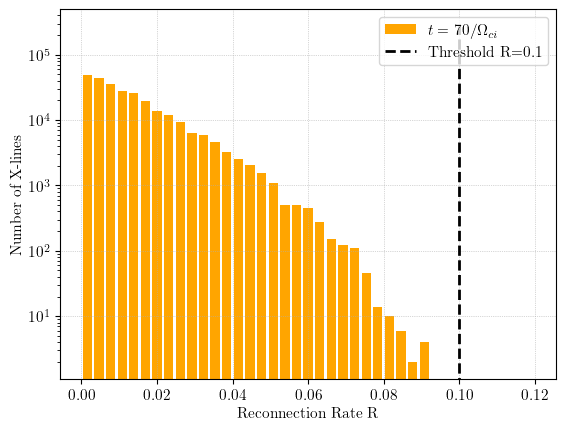

Processing /home/max/Temp/reconnection_rates_step_0114.txt


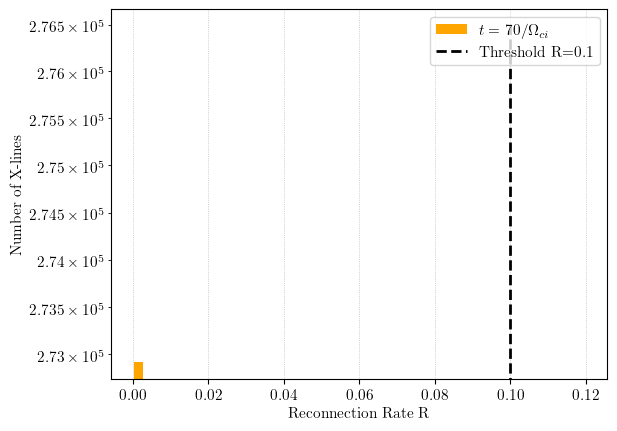

In [11]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    if len(data) == 0:
        print(f"Warning: No data found in {datapath}. Skipping.")
        return 0.0, np.array([])
    # data2 = np.loadtxt(all_files[60])
    # data = np.copy(data[np.where(data > 0.0)])
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    # x2, bins2 = np.histogram(data2, bins=bins, density=True)
    # plt.plot(bins[:-1], x2, ".-", linewidth=1.5, color=gradient[step], label=f"Step {step + 1}")
    plt.hist(data, bins=bins, density=False, color="orange", label="$t=70/\Omega_{ci}$", rwidth=0.8)
    # plt.show()
    return np.max(x), data


bins=40  
max_reconnection_rate = 0.12

plt.figure(figsize=(5,4), dpi=150)

max_val = 0.0
all_data = np.array([])
for i, datapath in enumerate(all_files):
    print(f"Processing {datapath}")
    max_val_new, data = plot_histogram(i, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)
    all_data = np.concatenate((all_data, data))
    if max_val_new > max_val:
        max_val = max_val_new
        
    plt.vlines(0.1, 0.0, max_val, color="black", linestyle="--", linewidth=2.0, label="Threshold R=0.1")
    # plt.hlines(10.0, 0.0, 0.2, color="gray", linestyle="--", linewidth=2.0, label="Noise Level")
    plt.yscale("log")
    # plt.xscale("log")
    plt.xlabel("Reconnection Rate R")
    plt.ylabel("Number of X-lines")
    plt.legend()
    
    plt.show()

# bins = np.linspace(0.0, max_reconnection_rate, bins) 
# x, bins = np.histogram(all_data, bins=bins, density=False)
# plt.plot(bins[:-1], x, linewidth=1.5, color="black", label="Histogram")
# max_val = np.max(x)



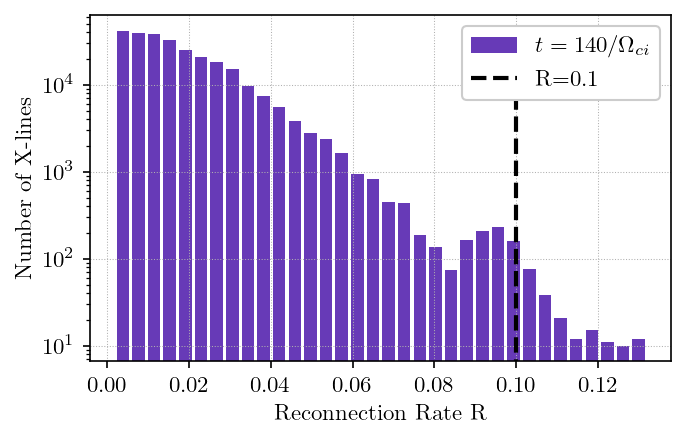

In [60]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    plt.hist(data, bins=bins, density=False, color=gcolor("violet"), label=r"$t=140/\Omega_{ci}$", rwidth=0.8, align="right")
    # plt.show()
    return np.max(x), data

datapath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_3.txt"
bins=35
max_reconnection_rate = 0.13

plt.figure(figsize=(5,3), dpi=150)

max_val_new, data = plot_histogram(1, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)

plt.vlines(0.1, 0.0, max_val_new, color="black", linestyle="--", linewidth=2.0, label="R=0.1")
plt.yscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend(framealpha=1.0)
plt.savefig("reconnection_rate_histogram.png", bbox_inches="tight", dpi=300)

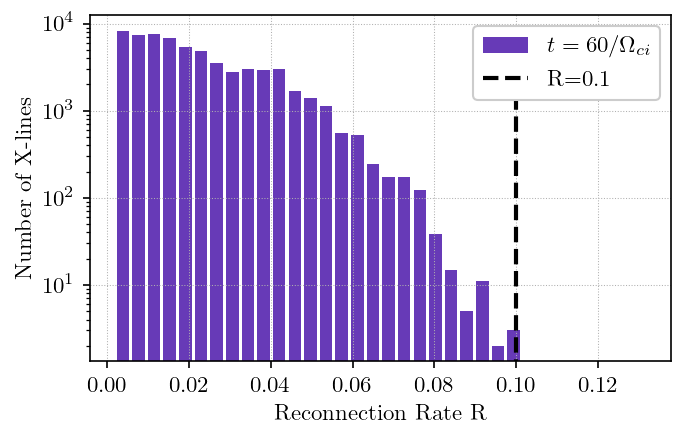

In [67]:

gradient = ["black", "orange", "green"]

def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    plt.hist(data, bins=bins, density=False, color=gcolor("violet"), label=r"$t=60/\Omega_{ci}$", rwidth=0.8, align="right")
    # plt.show()
    return np.max(x), data

datapath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_quasiXlines/reconnection_rates_step_0034.txt"
bins=35
max_reconnection_rate = 0.13

plt.figure(figsize=(5,3), dpi=150)

max_val_new, data = plot_histogram(1, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)

plt.vlines(0.1, 0.0, max_val_new, color="black", linestyle="--", linewidth=2.0, label="R=0.1")
plt.yscale("log")
plt.xlabel("Reconnection Rate R")
plt.ylabel("Number of X-lines")
plt.legend(framealpha=1.0)
plt.savefig("reconnection_rate_histogram_step_30.png", bbox_inches="tight", dpi=300)

<Figure size 600x450 with 0 Axes>

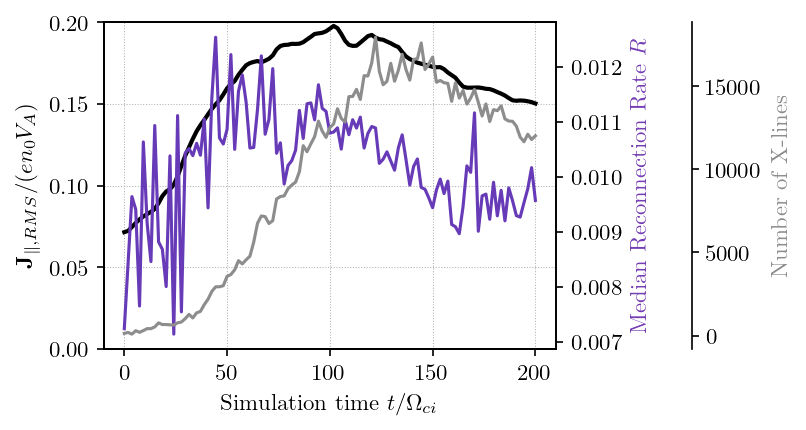

In [64]:
current_density = np.loadtxt("/home/max/Repos/Magnetic-Reconnection-Visualization/data/solar_wind_current_density.dat")

def get_max_reconnection(datapath):
    data = np.loadtxt(datapath)
    n = len(data)
    if n == 0:
        return 0.0, 0
    data = np.copy(data[np.where(data > 0.0)])
    data = np.copy(data[np.where(data < 1.0)])
    max_r = np.median(data)
    
    return max_r, len(data)

plt.figure(figsize=(4,3), dpi=150)

max_reconnection_rates = []
number_of_lines = []
time_steps = []
for i, datapath in enumerate(all_files):
    max_r, n = get_max_reconnection(datapath)
    max_reconnection_rates.append(max_r)
    number_of_lines.append(n)
    time_steps.append(i)

fig, ax1 = plt.subplots(figsize=(6,3), dpi=150)

averaged_reconnection_rates = [1/2*max_reconnection_rates[i]*max_reconnection_rates[i+1] for i in np.arange(0, len(max_reconnection_rates)-1)[::2]]

ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines.right.set_position(("axes", 1.3))

xlin = np.linspace(0, 200, len(max_reconnection_rates))

ax3.plot(xlin,number_of_lines, color="#8D8D8D", linewidth=1.5)
ax3.set_ylabel("Number of X-lines", color="#8D8D8D")
ax3.grid(False)

ax1.plot(xlin,current_density[:,1], color="black", linewidth=2)
ax1.set_ylim(0,0.2)
ax1.set_xlabel(r"Simulation time $t/\Omega_{ci}$")
ax1.set_ylabel(r"$\mathbf{J}_{\|,RMS}/(e n_0 V_A)$", color="black")

ax2.plot(xlin, max_reconnection_rates, color=gcolor("violet"), linewidth=1.5, label="Reconnection Rate $R$")
ax2.set_ylabel("Median Reconnection Rate $R$", color="#743db4")
ax2.grid(False)


plt.tight_layout()
plt.savefig("num_points_lines.png", dpi=300)
plt.show()